In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm
import pickle

In [2]:
# Load Background Solutions
with open("./numpyArr/Rgrid.pkl", "rb") as f:                        
    # binary read
    Rgrid = pickle.load(f)

with open("./numpyArr/PMSol.pkl", "rb") as f:                        
    # binary read
    PMSol = pickle.load(f)

with open("./numpyArr/H00Grid.pkl", "rb") as f:                        
    # binary read
    H00Grid = pickle.load(f)

with open("./numpyArr/NuGrid.pkl", "rb") as f:                        
    # binary read
    NuGrid = pickle.load(f)


## Initialization

In [3]:
# EOS (energy density vs pressure) for n = 1 polytrope
def EnergyEOS(p,K):
    rr=((1+np.sqrt(4*K*p))**2-1)/(4*K)
    return rr

In [4]:
G_cgs = 6.67430e-8     # cm^3 g^-1 s^2
c_cgs = 2.99792458e10  # cm s^-1
M_sun_cgs = 1.989e33   # g
cm2km = 1e5

def cgs_to_geom(p_cgs, n, K_cgs, eos=EnergyEOS):

    # km^-2
    p_geom = p_cgs * G_cgs / c_cgs**4 * cm2km**2            
    # km^(2/n)
    K_geom = K_cgs / G_cgs**(1/n) / c_cgs**(2-2/n) / cm2km**(2/n)               
    # Polytropic EOS, km^-2
    rho_geom = eos(p_geom, K_geom)               

    return K_geom, p_geom, rho_geom

K_cgs = 1.6e5
PcArr = np.logspace(33.5, 36.5, 20)

In [5]:
K, PcArr = cgs_to_geom(PcArr, 1, K_cgs)[:2]

solToUseID = 3 #
PMSolArr = np.array(PMSol[solToUseID])

# Pick the example background to use
RArr = np.array(Rgrid[solToUseID])
PArr = PMSolArr[:,1]
MArr = PMSolArr[:,0]

# Calculating the rho Array
RhoArr = EnergyEOS(PArr, K)

# Calculating the Lambda Array
LambArr = np.log( RArr/ (RArr-2*MArr) )

print(RArr.shape, PArr.shape, MArr.shape, RhoArr.shape, LambArr.shape)

(55093,) (55093,) (55093,) (55093,) (55093,)


In [6]:
# Calculating the first derivatives of rho, p, and dp/drho
# The last entry of each array in this grid is nan because of the nature of numpy's gradient function

DrhoArr = np.gradient(RhoArr, RArr, edge_order=2)
DpArr = np.gradient(PArr, RArr, edge_order=2)
Cs2Arr = np.gradient(PArr, RhoArr, edge_order=2)

print(DrhoArr.shape, DpArr.shape, Cs2Arr.shape)

(55093,) (55093,) (55093,)


In [7]:
# Loading h00 solution; these arrays are one dimension less.
H00r = np.array(H00Grid[solToUseID][:,0])
DH00r = np.array(H00Grid[solToUseID][:,1])

print(H00r.shape, DH00r.shape)

(55092,) (55092,)


## Importing the Source function

In [8]:
from importlib.machinery import SourceFileLoader
source_L2 = SourceFileLoader("source_L2", "source-L2.py").load_module()

FileNotFoundError: [Errno 2] No such file or directory: 'source-L2.py'

In [ ]:
# np.multiply(np.arange(0,5), np.arange(0,5))
np.arange(0,5)*np.arange(0,5)

array([ 0,  1,  4,  9, 16])

In [ ]:
SourceGrid = []
lenGrid = []
arrLenAll = []

for nnn in range(0,20):

    # The stellar model used in the current run
    solToUseID = nnn 
    PMSolArr = np.array(PMSol[solToUseID])

    # Pick the example background to use
    RArr = np.array(Rgrid[solToUseID])
    PArr = PMSolArr[:,1]
    MArr = PMSolArr[:,0]

    # Calculating the rho Array
    RhoArr = EnergyEOS(PArr, K)

    # Calculating the Lambda and Nu Array
    LambArr = np.log(RArr/(RArr-2*MArr))
    NuArr = NuGrid[solToUseID]

    # Calculating the Sound Speed Array, note this is one dimension less than the original array

    DrhoArr = np.gradient(RhoArr, RArr, edge_order=2)
    D2rhoArr = np.gradient(DrhoArr, RArr, edge_order=2)
    DpArr = np.gradient(PArr, RArr, edge_order=2)
    Cs2Arr = np.gradient(PArr, RhoArr, edge_order=2)

    H00r = np.array(H00Grid[solToUseID][:,0])
    DH00r = np.array(H00Grid[solToUseID][:,1])

    arrLen = np.min([np.shape(l) for l in [RArr, PArr, MArr, RhoArr, LambArr, NuArr, DrhoArr, DpArr, Cs2Arr, H00r, DH00r]])
    arrLenAll.append(arrLen)
    print(arrLen)
    

    T = 6*10**(-6)
    # eta_arr = T * RhoArr[:arrLen-4]**2
    # deta_arr = 2 * T * RhoArr[:arrLen-4] * DrhoArr[:arrLen-4]
    # d2eta_arr = 2 * T * (RhoArr[:arrLen-4] * D2rhoArr[:arrLen-4] + DrhoArr[:arrLen-4]**2)

    eta_arr = T * RhoArr[:arrLen-4]**2
    deta_arr = 2 * T * RhoArr[:arrLen-4]
    d2eta_arr = 2 * T 

    # Calling the source function
    S_h00 = source_L2.sourceH00(
        r=RArr[:arrLen-4],
        p0=PArr[:arrLen-4],
        rho0=RhoArr[:arrLen-4],
        drho0=DrhoArr[:arrLen-4],
        d2rho0=np.gradient(DrhoArr, RArr, edge_order=2)[:arrLen-4],
        h00=H00r[:arrLen-4],
        dh00=DH00r[:arrLen-4],
        lamb=LambArr[:arrLen-4],
        nu=NuArr[:arrLen-4],
        eta=eta_arr,      # η(ρ0)
        deta=deta_arr,    # dη/dr at ρ0（Chain rule)
        d2eta=d2eta_arr,  # d²η/dr² at ρ0（Chain rule)
    )

    SourceGrid.append(S_h00)
    lenGrid.append(arrLen-4)


    

57487
56798
56003
55092
54057
52890
51588
50151
48583
46895
45101
43224
41288
39323
37360
35432
33570
31803
30159
28661


0 57483 (57483,)
1 56794 (56794,)
2 55999 (55999,)
3 55088 (55088,)
4 54053 (54053,)
5 52886 (52886,)
6 51584 (51584,)
7 50147 (50147,)
8 48579 (48579,)
9 46891 (46891,)
10 45097 (45097,)
11 43220 (43220,)
12 41284 (41284,)
13 39319 (39319,)
14 37356 (37356,)
15 35428 (35428,)
16 33566 (33566,)
17 31799 (31799,)
18 30155 (30155,)
19 28657 (28657,)


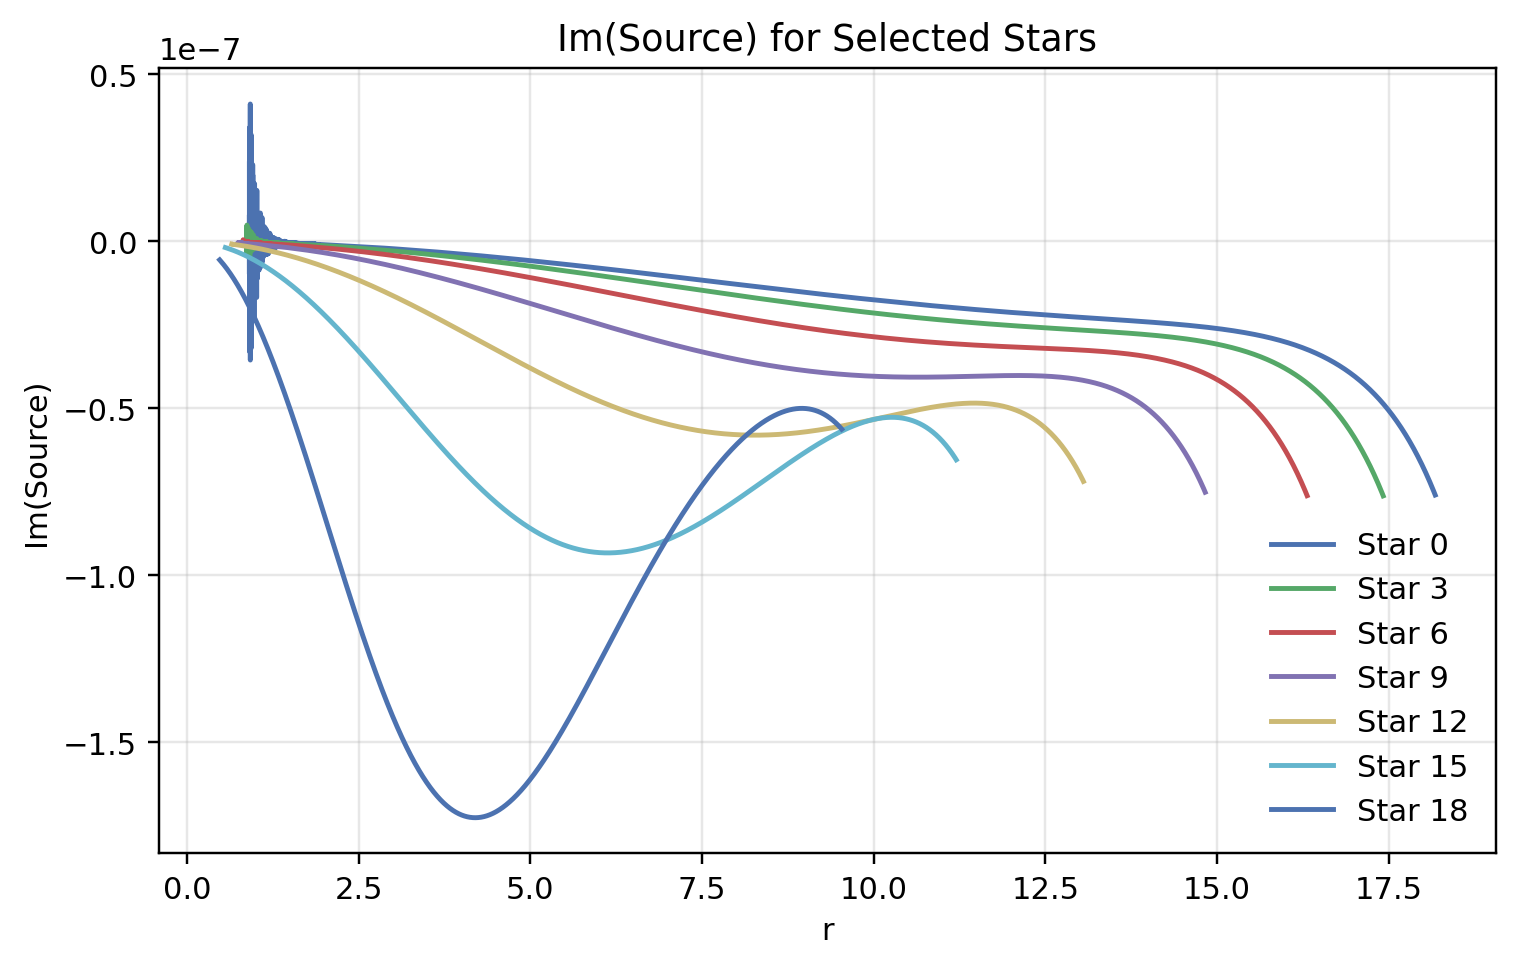

In [ ]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-deep")

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=220)

for i, arrL in enumerate(lenGrid[:20]):
    print(i, arrL, np.shape(SourceGrid[i]))
    if i % 3 == 0:
        start = arrL // 20
        ax.plot(
            Rgrid[i][start:arrL],
            SourceGrid[i][start:arrL].imag,
            label=f"Star {i}",
            lw=1.6,
        )

ax.set_xlabel("r")
ax.set_ylabel("Im(Source)")
ax.set_title("Im(Source) for Selected Stars")
ax.grid(alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## Matching the Analytical and Numerical Solution

In [ ]:
def source_analytical_o3(r, K, pc, nuc, h2, T):
    s = np.sqrt(K * pc)
    pi = np.pi
    prefactor = -0.5 * np.exp(-nuc / 2.0) * h2 * pi * r**2 * T
    denom = K**2 * (1 + 4 * s)**6

    poly = (
        21
        + 565248 * K**5 * pc**5
        + 460 * s
        + 128 * K**4 * pc**4 * (25259 + 15962 * s)
        + 20 * K**2 * pc**2 * (10234 + 36097 * s)
        + K * pc * (5287 + 39904 * s)
        + 16 * K**3 * pc**3 * (110495 + 185497 * s)
    )

    return prefactor * poly / denom

def source_analytical_o3_noh00(r, K, pc, nuc, h00, h00p, T):
    s = np.sqrt(K * pc)
    pi = np.pi
    prefactor = np.exp(-nuc / 2.0) * T / (18 * K**3 * s * (1 + 4 * s)**8 * r**2)

    poly_h00p = (
        318 * s * pi**2 * r**4
        + K * pi * r**2 * (
            -471 * s + 2 * pc * (2845 + 22741 * s) * pi * r**2
        )
        + K**2 * (
            324 * s
            - 9 * pc * (1156 + 11621 * s) * pi * r**2
            + 28 * pc**2 * (8571 + 44132 * s) * pi**2 * r**4
        )
        + 2048 * K**7 * pc**5 * (
            54 * (111 + 28 * s)
            - 6 * pc * (14849 + 3728 * s) * pi * r**2
            + pc**2 * (1567285 + 364076 * s) * pi**2 * r**4
        )
        + 12 * K**4 * pc**2 * (
            108 * (351 + 1393 * s)
            - pc * (897773 + 2798428 * s) * pi * r**2
            + 16 * pc**2 * (1281487 + 4791132 * s) * pi**2 * r**4
        )
        + 4 * K**3 * pc * (
            27 * (70 + 711 * s)
            - 6 * pc * (27266 + 123557 * s) * pi * r**2
            + 2 * pc**2 * (981323 + 6154245 * s) * pi**2 * r**4
        )
        + 128 * K**6 * pc**4 * (
            324 * (461 + 492 * s)
            - 12 * pc * (199629 + 203600 * s) * pi * r**2
            + 5 * pc**2 * (10630727 + 9536628 * s) * pi**2 * r**4
        )
        + 16 * K**5 * pc**3 * (
            1215 * (271 + 604 * s)
            - 3 * pc * (1883993 + 4080256 * s) * pi * r**2
            + 2 * pc**2 * (78857997 + 155380336 * s) * pi**2 * r**4
        )
    )

    poly_h00 = (
        921 * s * pi**2 * r**4
        + K * pi * r**2 * (
            -1131 * s + pc * (17918 + 166131 * s) * pi * r**2
        )
        + K**2 * (
            648 * s
            - 45 * pc * (588 + 6509 * s) * pi * r**2
            + 20 * pc**2 * (52462 + 270875 * s) * pi**2 * r**4
        )
        + 2048 * K**7 * pc**5 * (
            108 * (111 + 28 * s)
            - 6 * pc * (56953 + 14080 * s) * pi * r**2
            + pc**2 * (2449733 + 580468 * s) * pi**2 * r**4
        )
        + 8 * K**3 * pc * (
            27 * (70 + 711 * s)
            - 3 * pc * (88117 + 475303 * s) * pi * r**2
            + pc**2 * (3133222 + 13303569 * s) * pi**2 * r**4
        )
        + 12 * K**4 * pc**2 * (
            216 * (351 + 1393 * s)
            - pc * (4043929 + 13710596 * s) * pi * r**2
            + 4 * pc**2 * (8456940 + 27678479 * s) * pi**2 * r**4
        )
        + 128 * K**6 * pc**4 * (
            648 * (461 + 492 * s)
            - 12 * pc * (841029 + 809392 * s) * pi * r**2
            + pc**2 * (77916459 + 72443476 * s) * pi**2 * r**4
        )
        + 16 * K**5 * pc**3 * (
            2430 * (271 + 604 * s)
            - 33 * pc * (831107 + 1683856 * s) * pi * r**2
            + 2 * pc**2 * (109852587 + 219919234 * s) * pi**2 * r**4
        )
    )

    return prefactor * (-h00p * r * poly_h00p + h00 * poly_h00)


In [ ]:
def source_analytical_o5(r, K, pc, nuc, h2, T):
    s = np.sqrt(K * pc)
    pi = np.pi
    prefactor = -1.0 * np.exp(-nuc / 2.0) * h2 * pi * r**2 * T
    denom = 18 * K**3 * s * (1 + 4 * s)**7

    poly = (
        -285 * s * pi * r**2
        + 6144 * K**7 * pc**6 * (3312 + 12307 * pc * pi * r**2)
        + K * (189 * s - pc * (5398 + 53575 * s) * pi * r**2)
        + K**2 * pc * (
            9 * (544 + 7127 * s) - 4 * pc * (88741 + 381563 * s) * pi * r**2
        )
        + 4 * K**3 * pc**2 * (
            9 * (15263 + 91074 * s) + 2 * pc * (-407450 + 634721 * s) * pi * r**2
        )
        + 4 * K**4 * pc**3 * (
            45 * (77033 + 232784 * s) + 28 * pc * (587918 + 2212861 * s) * pi * r**2
        )
        + 128 * K**6 * pc**5 * (
            126 * (8357 + 4876 * s) + pc * (5082785 + 2591664 * s) * pi * r**2
        )
        + 16 * K**5 * pc**4 * (
            9 * (627477 + 944060 * s) + 2 * pc * (16883353 + 23308026 * s) * pi * r**2
        )
    )

    return prefactor * poly / denom

def source_analytical_o5_noh00(r, K, pc, nuc, h00, h00p, T):
    s = np.sqrt(K * pc)
    pi = np.pi
    prefactor = np.exp(-nuc / 2.0) * T / (162 * K**4 * (1 + 4 * s)**9 * r**2)

    poly_h00p = (
        27 * (39 + 500 * s) * pi**3 * r**6
        - 2 * K * pi**2 * r**4 * (9 * (159 + 3481 * s) + pc * (-18799 + 75106 * s) * pi * r**2)
        + K**2 * pi * r**2 * (
            27 * (157 + 4096 * s)
            - 18 * pc * (34121 + 210958 * s) * pi * r**2
            + 2 * pc**2 * (720141 + 24436004 * s) * pi**2 * r**4
        )
        + 8192 * K**8 * pc**5 * (
            -972 * (59 + 14 * s)
            + 54 * pc * (15781 + 3728 * s) * pi * r**2
            - 36 * pc**2 * (414576 + 91019 * s) * pi**2 * r**4
            + pc**3 * (101770613 + 21121484 * s) * pi**3 * r**6
        )
        + 512 * K**7 * pc**4 * (
            -5832 * (292 + 283 * s)
            + 108 * pc * (250529 + 233298 * s) * pi * r**2
            - 180 * pc**2 * (3253721 + 2697614 * s) * pi**2 * r**4
            + 11 * pc**3 * (429542497 + 324174060 * s) * pi**3 * r**6
        )
        + K**3 * (
            -972 * (3 + 82 * s)
            + 2565 * pc * (513 + 3764 * s) * pi * r**2
            - 504 * pc**2 * (39208 + 228453 * s) * pi**2 * r**4
            + 8 * pc**3 * (64967631 + 451115183 * s) * pi**3 * r**6
        )
        + 4 * K**4 * pc * (
            -243 * (991 + 7056 * s)
            + 27 * pc * (465242 + 1886229 * s) * pi * r**2
            - 234 * pc**2 * (775349 + 4259436 * s) * pi**2 * r**4
            + 8 * pc**3 * (593792354 + 2479496145 * s) * pi**3 * r**6
        )
        + 16 * K**5 * pc**2 * (
            -729 * (2797 + 9637 * s)
            + 81 * pc * (532460 + 1560807 * s) * pi * r**2
            - 270 * pc**2 * (3966832 + 12923011 * s) * pi**2 * r**4
            + 8 * pc**3 * (2066054055 + 5439110329 * s) * pi**3 * r**6
        )
        + 64 * K**6 * pc**3 * (
            -1458 * (3165 + 6374 * s)
            + 27 * pc * (2904057 + 5677288 * s) * pi * r**2
            - 18 * pc**2 * (117703081 + 208533971 * s) * pi**2 * r**4
            + 2 * pc**3 * (11087189027 + 17017266720 * s) * pi**3 * r**6
        )
    )

    poly_h00 = (
        27 * (153 + 2492 * s) * pi**3 * r**6
        + K * pi**2 * r**4 * (-9 * (921 + 21602 * s) + 2 * pc * (219866 + 853843 * s) * pi * r**2)
        + K**2 * pi * r**2 * (
            27 * (377 + 10328 * s)
            - 9 * pc * (237803 + 1713764 * s) * pi * r**2
            + 2 * pc**2 * (5302887 + 63484090 * s) * pi**2 * r**4
        )
        + 16384 * K**8 * pc**5 * (
            -972 * (59 + 14 * s)
            + 27 * pc * (60473 + 14080 * s) * pi * r**2
            - 9 * pc**2 * (1297425 + 290234 * s) * pi**2 * r**4
            + 52 * pc**3 * (3207167 + 669779 * s) * pi**3 * r**6
        )
        + 2048 * K**7 * pc**4 * (
            -2916 * (292 + 283 * s)
            + 27 * pc * (1043377 + 923298 * s) * pi * r**2
            - 18 * pc**2 * (12003416 + 10280301 * s) * pi**2 * r**4
            + 4 * pc**3 * (940146205 + 721586073 * s) * pi**3 * r**6
        )
        + K**3 * (
            -1944 * (3 + 82 * s)
            + 27 * pc * (132915 + 1095476 * s) * pi * r**2
            - 108 * pc**2 * (801205 + 3894648 * s) * pi**2 * r**4
            + 8 * pc**3 * (155282100 + 1122268429 * s) * pi**3 * r**6
        )
        + 4 * K**4 * pc * (
            -486 * (991 + 7056 * s)
            + 27 * pc * (1655542 + 7846353 * s) * pi * r**2
            - 18 * pc**2 * (25836457 + 103955916 * s) * pi**2 * r**4
            + 8 * pc**3 * (1563108973 + 6859420338 * s) * pi**3 * r**6
        )
        + 64 * K**6 * pc**3 * (
            -2916 * (3165 + 6374 * s)
            + 27 * pc * (13772781 + 25250648 * s) * pi * r**2
            - 9 * pc**2 * (329664791 + 595671386 * s) * pi**2 * r**4
            + 4 * pc**3 * (16895587025 + 26541654651 * s) * pi**3 * r**6
        )
        + 16 * K**5 * pc**2 * (
            -1458 * (2797 + 9637 * s)
            + 81 * pc * (2490526 + 7617591 * s) * pi * r**2
            - 27 * pc**2 * (61506239 + 183948974 * s) * pi**2 * r**4
            + 4 * pc**3 * (11888763855 + 32291822641 * s) * pi**3 * r**6
        )
    )

    return prefactor * (h00p * r * poly_h00p - h00 * poly_h00)


In [ ]:
def source_analytical_o7(r, K, pc, nuc, h2, T):
    s = np.sqrt(K * pc)
    pi = np.pi
    prefactor = -1.0 * np.exp(-nuc / 2.0) * h2 * pi * r**2 * T
    denom = 54 * K**4 * (1 + 4 * s)**8

    poly = (
        9 * (75 + 1192 * s) * pi**2 * r**4
        + K * pi * r**2 * (
            -3 * (285 + 6538 * s) + 10 * pc * (7860 + 35497 * s) * pi * r**2
        )
        + 8192 * K**8 * pc**6 * (
            29808 + 110763 * pc * pi * r**2 + 2284504 * pc**2 * pi**2 * r**4
        )
        + K**2 * (
            27 * (21 + 628 * s)
            - 3 * pc * (75167 + 569264 * s) * pi * r**2
            + 2 * pc**2 * (577595 + 2560314 * s) * pi**2 * r**4
        )
        + 36 * K**4 * pc**2 * (
            456378 + 2248383 * s
            + 2 * pc * (-331693 + 3589912 * s) * pi * r**2
            + 16 * pc**2 * (4187959 + 18441276 * s) * pi**2 * r**4
        )
        + 512 * K**7 * pc**5 * (
            216 * (16758 + 9085 * s)
            + 3 * pc * (5730701 + 2739348 * s) * pi * r**2
            + 4 * pc**2 * (81686361 + 41050210 * s) * pi**2 * r**4
        )
        + K**3 * pc * (
            27 * (9303 + 89560 * s)
            - 396 * pc * (22319 + 70944 * s) * pi * r**2
            + 8 * pc**2 * (5888632 + 49791493 * s) * pi**2 * r**4
        )
        + 48 * K**5 * pc**3 * (
            9 * (676145 + 1791397 * s)
            + 3 * pc * (10650577 + 31908938 * s) * pi * r**2
            + 4 * pc**2 * (181432203 + 444869113 * s) * pi**2 * r**4
        )
        + 64 * K**6 * pc**4 * (
            108 * (215873 + 294514 * s)
            + 3 * pc * (45420719 + 56781622 * s) * pi * r**2
            + 4 * pc**2 * (601525327 + 768694669 * s) * pi**2 * r**4
        )
    )

    return prefactor * poly / denom

def source_analytical_o7_v2(r, K, pc, nuc, T, a0=1):
    s = np.sqrt(K * pc)
    pi = np.pi

    prefactor = a0 * np.exp(-nuc / 2.0) * pc * pi * r**2 * T

    denom = (
        74844
        * K**3
        * (4 * K * pc + s)
        * (1 + 4 * s)**8
        * (1 + 48 * K * pc + 12 * s + 64 * (K * pc)**(3/2))
        * (
            16384 * K**4 * pc**4
            + s
            + 2240 * K**2 * pc**2 * (1 + 4 * s)
            + 7168 * K**3 * pc**3 * (3 + 4 * s)
            + 28 * K * (pc + 12 * pc * s)
        )
    )

    poly = (
        -3 * (223059 + 13132700 * s) * pi**2 * r**4
        + K * pi * r**2 * (
            3564 * (195 + 12832 * s)
            - pc * (1090113941 + 18772404212 * s) * pi * r**2
        )
        + 34359738368 * K**13 * pc**11 * (
            -2673 * (75235 + 10976 * s)
            - 198 * pc * (9222578 + 1286333 * s) * pi * r**2
            + pc**2 * (8632684757 + 1206132880 * s) * pi**2 * r**4
        )
        + 6442450944 * K**12 * pc**10 * (
            -891 * (8174731 + 3938084 * s)
            - 33 * pc * (2094100753 + 993405438 * s) * pi * r**2
            + 20 * pc**2 * (16890228041 + 7833442697 * s) * pi**2 * r**4
        )
        - 6 * K**3 * pc * (
            891 * (209017 + 4972868 * s)
            - 132 * pc * (542173595 + 6060822957 * s) * pi * r**2
            + 32 * pc**2 * (60958531077 + 221256592432 * s) * pi**2 * r**4
        )
        - 2 * K**2 * (
            13365 * (15 + 1136 * s)
            - 198 * pc * (3655029 + 74180587 * s) * pi * r**2
            + 4 * pc**2 * (27960599493 + 240166776869 * s) * pi**2 * r**4
        )
        + 134217728 * K**11 * pc**9 * (
            -13365 * (43146147 + 38632580 * s)
            - 198 * pc * (27651999237 + 24861417545 * s) * pi * r**2
            + pc**2 * (29024855679771 + 24902020093960 * s) * pi**2 * r**4
        )
        + 8 * K**4 * pc**2 * (
            -2673 * (21440830 + 284606819 * s)
            + 396 * pc * (13369761842 + 94217605223 * s) * pi * r**2
            + 2 * pc**2 * (2515488093013 + 130750051852760 * s) * pi**2 * r**4
        )
        + 8388608 * K**10 * pc**8 * (
            -8019 * (711437341 + 1008685164 * s)
            - 2079 * pc * (25159545667 + 36474381142 * s) * pi * r**2
            + 2 * pc**2 * (159566060659507 + 213706442533546 * s) * pi**2 * r**4
        )
        + 32 * K**5 * pc**3 * (
            -8019 * (251032468 + 2166053593 * s)
            + 297 * pc * (175150510725 + 737840148698 * s) * pi * r**2
            + 4 * pc**2 * (157479723445269 + 1056207377960107 * s) * pi**2 * r**4
        )
        + 32768 * K**8 * pc**6 * (
            -2673 * (20124251329 + 60105902204 * s)
            - 99 * pc * (3699634069503 + 12581972202122 * s) * pi * r**2
            + 4 * pc**2 * (1096457093275308 + 2890818659569729 * s) * pi**2 * r**4
        )
        + 524288 * K**9 * pc**7 * (
            -2673 * (9417324505 + 19707954852 * s)
            - 198 * pc * (1068496349362 + 2356431119019 * s) * pi * r**2
            + pc**2 * (1637244063329243 + 3154556321124144 * s) * pi**2 * r**4
        )
        + 128 * K**6 * pc**4 * (
            -24057 * (1287941397 + 7669694860 * s)
            - 297 * pc * (-490952276645 + 129484856846 * s) * pi * r**2
            + 2 * pc**2 * (2864003424731399 + 13207584049325190 * s) * pi**2 * r**4
        )
        + 2048 * K**7 * pc**5 * (
            -2673 * (21565031333 + 90766366652 * s)
            - 198 * pc * (977140505509 + 6645672997483 * s) * pi * r**2
            + pc**2 * (6604782796975109 + 23061520446875400 * s) * pi**2 * r**4
        )
    )

    return prefactor * poly / denom

def source_analytical_o7_noh00(r, K, pc, nuc, h00, h00p, T):
    s = np.sqrt(K * pc)
    pi = np.pi
    prefactor = -1.0 * np.exp(-nuc / 2.0) * T / (2430 * K**5 * s * (1 + 4 * s)**10 * r**2)

    poly_h00 = (
        -29160 * (1 + s)**2 * (K + 4 * K * s)**4
        * (3 * s + 64 * K**3 * pc**3 * (41 + 28 * s) + 4 * K * pc * (10 + 53 * s)
           + 4 * K**2 * pc**2 * (163 + 388 * s))
        + 405 * s * (K + 4 * K * s)**3 * (
            377 + 7312 * s
            + 1024 * K**5 * pc**5 * (53433 + 14080 * s)
            + K * pc * (68387 + 431388 * s)
            + 64 * K**4 * pc**4 * (1330795 + 1405052 * s)
            + 4 * K**2 * pc**2 * (519218 + 1967057 * s)
            + 16 * K**3 * pc**3 * (1460592 + 3299809 * s)
        ) * pi * r**2
        - 135 * K**2 * (1 + 4 * s)**2 * (
            921 * s
            + K * pc * (17918 + 166131 * s)
            + 20 * K**2 * pc**2 * (52462 + 270875 * s)
            + 2048 * K**7 * pc**7 * (2449733 + 580468 * s)
            + 8 * K**3 * pc**3 * (3133222 + 13303569 * s)
            + 48 * K**4 * pc**4 * (8456940 + 27678479 * s)
            + 128 * K**6 * pc**6 * (77916459 + 72443476 * s)
            + 32 * K**5 * pc**5 * (109852587 + 219919234 * s)
        ) * pi**2 * r**4
        + 15 * K * s * (1 + 4 * s) * (
            4131 + 67284 * s
            + 851968 * K**8 * pc**8 * (3207167 + 669779 * s)
            + 2 * K * pc * (219866 + 853843 * s)
            + 2 * K**2 * pc**2 * (5302887 + 63484090 * s)
            + 8192 * K**7 * pc**7 * (940146205 + 721586073 * s)
            + 8 * K**3 * pc**3 * (155282100 + 1122268429 * s)
            + 32 * K**4 * pc**4 * (1563108973 + 6859420338 * s)
            + 256 * K**6 * pc**6 * (16895587025 + 26541654651 * s)
            + 64 * K**5 * pc**5 * (11888763855 + 32291822641 * s)
        ) * pi**3 * r**6
        - (
            18225 * s
            - 90 * K * pc * (-972 + 28547 * s)
            - 2 * K**2 * pc**2 * (16068400 + 57362973 * s)
            + 8 * K**3 * pc**3 * (63792121 + 1070215038 * s)
            + 96 * K**4 * pc**4 * (661720352 + 4174137091 * s)
            + 32768 * K**10 * pc**10 * (36813103875 + 7084169468 * s)
            + 32 * K**5 * pc**5 * (76324278280 + 422883420183 * s)
            + 320 * K**6 * pc**6 * (196884264389 + 740696544992 * s)
            + 3072 * K**8 * pc**8 * (985497958096 + 1355554927993 * s)
            + 2048 * K**9 * pc**9 * (2039506723761 + 1402680523228 * s)
            + 256 * K**7 * pc**7 * (2768440581465 + 6503630449961 * s)
        ) * pi**4 * r**8
    )

    poly_h00p = (
        14580 * K**4 * s * (1 + s)**2 * (1 + 4 * s)**5
        * (3 + 100 * K * pc + 544 * K**2 * pc**2 + 28 * s + 252 * (K * pc)**1.5
           + 448 * (K * pc)**2.5) * r
        - 405 * K**3 * (1 + 4 * s)**4 * (
            157 * s
            + 256 * K**5 * pc**5 * (12985 + 3728 * s)
            + 156 * K**3 * pc**3 * (4507 + 12108 * s)
            + K * pc * (2212 + 14655 * s)
            + 8 * K**2 * pc**2 * (8187 + 28751 * s)
            + 16 * K**4 * pc**4 * (236477 + 299592 * s)
        ) * pi * r**3
        + 270 * K**2 * (1 + 4 * s)**3 * (
            93203456 * K**7 * pc**7
            + 159 * s
            + K * pc * (2209 + 13905 * s)
            + 2 * K**2 * pc**2 * (32187 + 180176 * s)
            + 4 * K**3 * pc**3 * (620971 + 3670361 * s)
            + 64 * K**6 * pc**6 * (10444519 + 5905064 * s)
            + 16 * K**4 * pc**4 * (4018561 + 12672548 * s)
            + 16 * K**5 * pc**5 * (28167805 + 42709116 * s)
        ) * pi**2 * r**5
        - 15 * K * s * (1 + 4 * s)**2 * (
            43256799232 * K**8 * pc**8
            + 2 * K * pc * (223 - 75998 * s)
            + 27 * (39 + 344 * s)
            + 2 * K**2 * pc**2 * (1024133 + 20339472 * s)
            + 4608 * K**7 * pc**7 * (88332047 + 42884552 * s)
            + 8 * K**3 * pc**3 * (44628159 + 272602547 * s)
            + 96 * K**4 * pc**4 * (107063269 + 398245639 * s)
            + 128 * K**5 * pc**5 * (871317138 + 1953841777 * s)
            + 128 * K**6 * pc**6 * (3271821919 + 3929979044 * s)
        ) * pi**3 * r**7
        + 2 * s * (1 + 4 * s) * (
            135 * (9 - 202 * s)
            - 50 * K * pc * (12249 + 77783 * s)
            + 2 * K**2 * pc**2 * (-3735733 + 2123630 * s)
            + 24576 * K**9 * pc**9 * (1426481877 + 284286542 * s)
            - 4 * K**3 * pc**3 * (66263077 + 810616616 * s)
            + 8 * K**4 * pc**4 * (-1592477119 + 2388883326 * s)
            + 480 * K**5 * pc**5 * (1035559578 + 6453351125 * s)
            + 1280 * K**6 * pc**6 * (9441814261 + 26217062570 * s)
            + 1024 * K**8 * pc**8 * (107605039657 + 78072872221 * s)
            + 256 * K**7 * pc**7 * (267700232761 + 401345489000 * s)
        ) * pi**4 * r**9
    )

    return prefactor * (h00 * poly_h00 + h00p * poly_h00p)


In [ ]:
anal_source_o3 = []
anal_source_o5 = []
anal_source_o7 = []
# Constants Needed (r, K, pc, nuc, h2, T)

K_cgs = 1.6e5
PcArr = np.logspace(33.5, 36.5, 20)
K, PcArr = cgs_to_geom(PcArr, 1, K_cgs)[:2]

for nnn in tqdm(range(0,20)):
    solToUseID = nnn
    
    RArr = np.array(Rgrid[solToUseID])
    
    # Index at stellar surface
    SurfaceIndex = arrLenAll[solToUseID] - 4
    
    pc = PcArr[solToUseID]
    h2 = 1
    # T = 6*10**(-6) 
    NuArr = NuGrid[solToUseID]
    nuc = NuArr[0]

    anal_source_o3.append(source_analytical_o3(RArr, K, pc, nuc, h2, T))
    anal_source_o5.append(source_analytical_o5(RArr, K, pc, nuc, h2, T))
    anal_source_o7.append(source_analytical_o7(RArr, K, pc, nuc, h2, T))

100%|██████████| 20/20 [00:00<00:00, 202.53it/s]


In [ ]:
anal_source_o3_v2 = []
anal_source_o5_v2 = []
anal_source_o7_v2 = []
# Constants Needed (r, K, pc, nuc, T, a0=1)

K_cgs = 1.6e5
PcArr = np.logspace(33.5, 36.5, 20)
K, PcArr = cgs_to_geom(PcArr, 1, K_cgs)[:2]

for nnn in tqdm(range(0,20)):
    solToUseID = nnn
    
    RArr = np.array(Rgrid[solToUseID])
    
    # Index at stellar surface
    SurfaceIndex = arrLenAll[solToUseID] - 4
    # Index to start
    startIndex = 0

    H00r = np.array(H00Grid[solToUseID][:,0])
    DH00r = np.array(H00Grid[solToUseID][:,1])
    
    pc = PcArr[solToUseID]

    # Using scaled numerical h00 to determine the scaling factor a0 to use
    scaledH00Num = H00r[startIndex:SurfaceIndex]/(RArr[startIndex:SurfaceIndex]**2)
    sliceWidth = int(SurfaceIndex*0.005)
    for i in range(startIndex, SurfaceIndex-sliceWidth):
        # Compute the variance of scaled h00 within the slice
        varNumH00 = np.var(scaledH00Num[i:i + sliceWidth])
        if varNumH00 < 10**(-8): break
    
    pc = PcArr[solToUseID]
    # a0 = int(scaledH00Num[i]*10**3)/(10**3) - 0.0075
    a0 = 0.23
    # T = 6*10**(-6) 
    NuArr = NuGrid[solToUseID]
    nuc = NuArr[0]

    # anal_source_o3.append(source_analytical_o3(RArr, K, pc, nuc, T))
    # anal_source_o5.append(source_analytical_o5(RArr, K, pc, nuc, T))
    anal_source_o7_v2.append(source_analytical_o7_v2(RArr, K, pc, nuc, T, a0=a0))

100%|██████████| 20/20 [00:00<00:00, 102.60it/s]


100%|██████████| 20/20 [00:00<00:00, 236.16it/s]


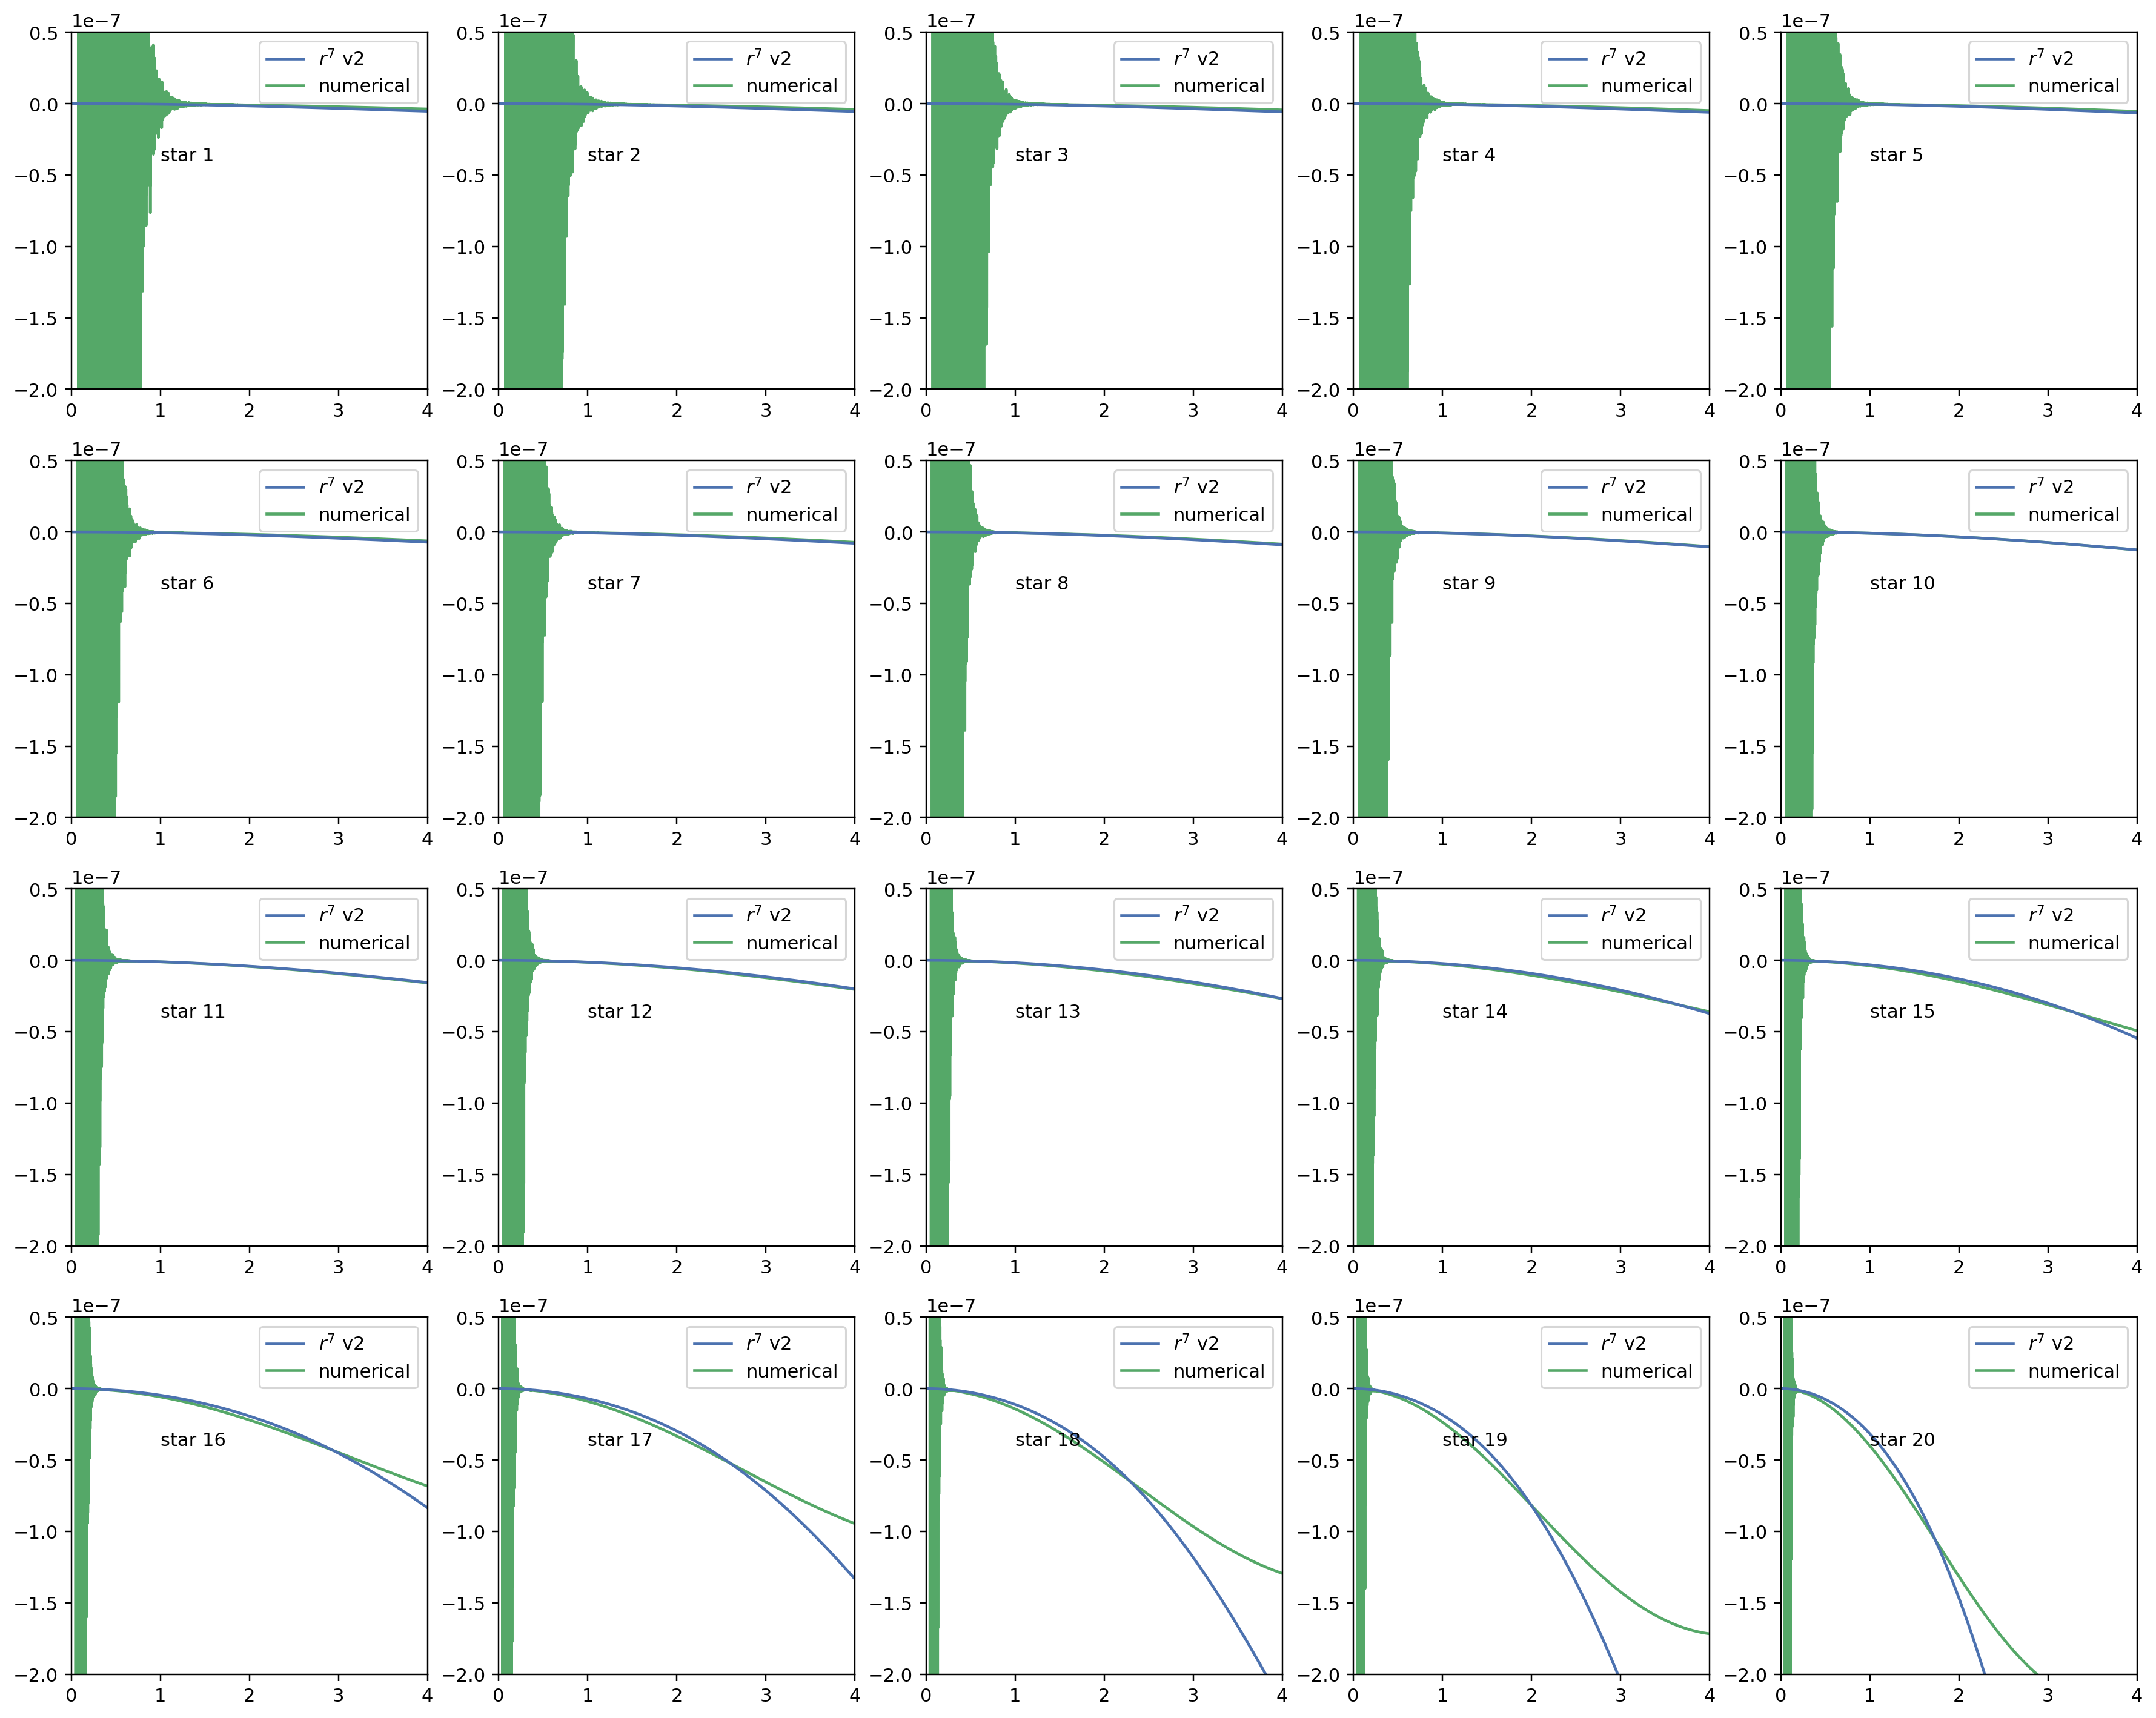

In [ ]:
fig, axs = plt.subplots(4, 5, figsize=(20,16), dpi=220)

for nnn in tqdm(range(0,20)):

    solToUseID = int(nnn)
    
    RArr = np.array(Rgrid[solToUseID])

    # Index at stellar surface
    SurfaceIndex = arrLenAll[solToUseID] - 4
    
    # axs[nnn//5, nnn%5].plot(RArr, anal_source_o3[solToUseID], label=r"$r^3$")
    # axs[nnn//5, nnn%5].plot(RArr, anal_source_o5[solToUseID], label=r"$r^5$")
    # axs[nnn//5, nnn%5].plot(RArr, anal_source_o7[solToUseID], label=r"$r^7$")
    axs[nnn//5, nnn%5].plot(RArr, anal_source_o7_v2[solToUseID], label=r"$r^7$ v2")

    startIndex = int(SurfaceIndex/230)
    axs[nnn//5, nnn%5].plot(RArr[startIndex:SurfaceIndex], SourceGrid[solToUseID][startIndex:SurfaceIndex].imag, zorder=-100, label="numerical")

    axs[nnn//5, nnn%5].set_ylim(-2e-7,5e-8)
    axs[nnn//5, nnn%5].set_xlim(0,4)
    axs[nnn//5, nnn%5].text(1, -4e-8, f"star {nnn+1}")
    axs[nnn//5, nnn%5].legend()


100%|██████████| 20/20 [00:00<00:00, 89.77it/s]


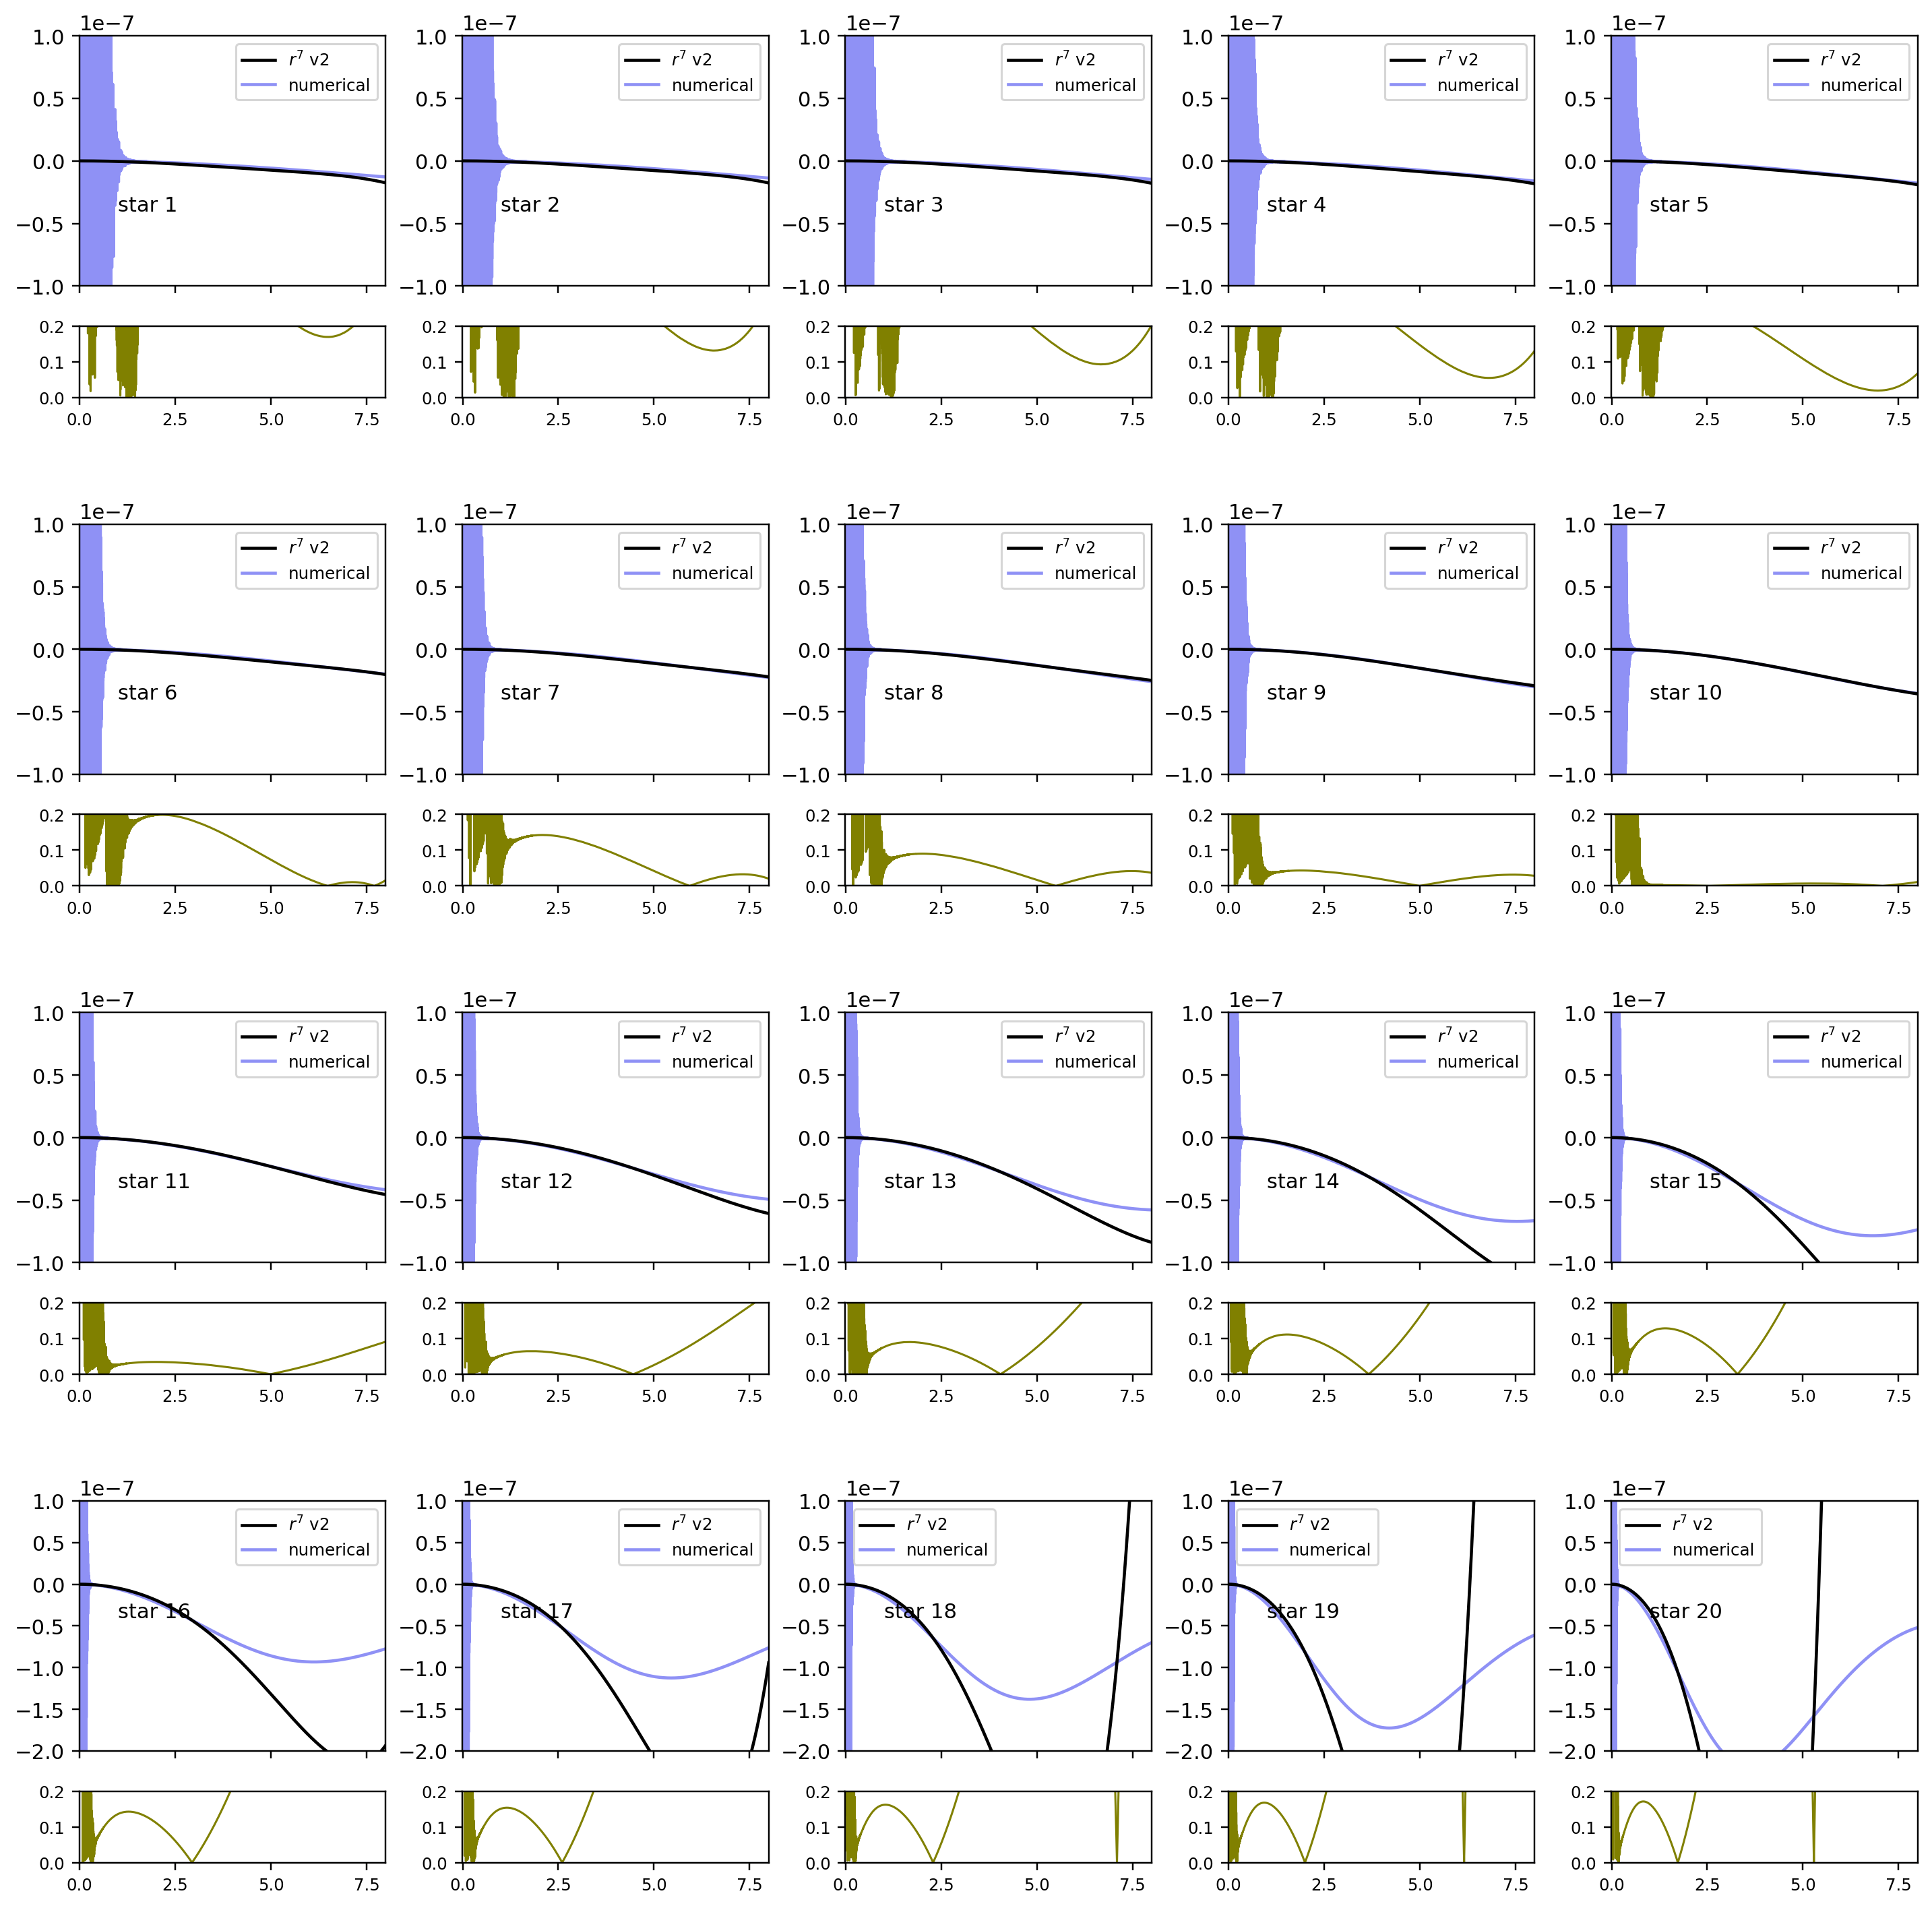

In [ ]:
fig = plt.figure(figsize=(16, 16), dpi=220)
outer = fig.add_gridspec(4, 5, wspace=0.25, hspace=0.35)

for nnn in tqdm(range(0, 20)):
    solToUseID = int(nnn)

    RArr = np.array(Rgrid[solToUseID])
    SurfaceIndex = arrLenAll[solToUseID] - 4

    startIndex = 0 # int(SurfaceIndex / 230)

    # --- dividing in subplots ---
    inner = outer[nnn // 5, nnn % 5].subgridspec(
        2, 1, height_ratios=[3.5, 1], hspace=0.25
    )
    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    # =========================
    # Top panel: comparison of analytical and numerical
    # =========================
    ax_top.plot(
        RArr[:SurfaceIndex],
        anal_source_o7_v2[solToUseID][:SurfaceIndex], 
        label=r"$r^7$ v2",
        color="black",
    )

    src_imag = np.array(SourceGrid[solToUseID]).imag
    ax_top.plot(
        RArr[startIndex:SurfaceIndex],
        src_imag[startIndex:SurfaceIndex],
        zorder=-100,
        label="numerical",
        color="#2025ed",
        alpha=0.5,
    )

    ax_top.set_ylim(-1e-7, 1e-7)
    if nnn >= 15:
        ax_top.set_ylim(-2e-7, 1e-7)
    ax_top.set_xlim(-0.01, 8)
    ax_top.text(1, -4e-8, f"star {nnn+1}")
    ax_top.legend(fontsize=8)

    # No tick text on x-axis
    ax_top.tick_params(labelbottom=False)

    # =========================
    # Bottom Plots (numerical - analytic)
    # =========================


    softening = np.max(np.abs(src_imag[int(SurfaceIndex*0.1): int(SurfaceIndex*0.2)]))*0.1

    # print(softening)
    
    # diff_o3 = np.abs(src_imag - np.array(anal_source_o3_original_h00[solToUseID]))/(np.abs(src_imag) + softening)
    # diff_o5 = np.abs(src_imag - np.array(anal_source_o5_original_h00[solToUseID]))/(np.abs(src_imag) + softening)
    diff_o7_v2 = np.abs(src_imag - np.array(anal_source_o7_v2[solToUseID][:SurfaceIndex]))/(np.abs(src_imag) + softening)

    ax_bot.axhline(0.0, lw=0.8, alpha=0.6)
    
    ax_bot.plot(
        RArr[startIndex:SurfaceIndex],
        diff_o7_v2[startIndex:SurfaceIndex],
        color="olive",
        label=r"num - $r^7$",
        lw=1.0,
    )


    ax_bot.set_ylim(0.0, 0.2)
    # ax_bot.set_yscale("log")
    ax_bot.set_xlim(-0.01, 8)
    ax_bot.tick_params(labelsize=8)

plt.show()


## Checking correspondence between numerical and analytical $h_{00}$

In [ ]:
def h00_series_from_mathematica(r, K, pc, a0, a8=0):
    """
    Vectorized h00(r) from the given Mathematica expression, treating ε = r.

    Parameters
    ----------
    r : array_like
        Radius grid (can be scalar or numpy array)
    K, pc : float
        Background parameters
    a0, a8 : float
        Known series coefficients appearing in the expression

    Returns
    -------
    h00 : ndarray
        h00 evaluated on r-grid (same shape as r)
    """
    r = np.asarray(r, dtype=float)
    pi = np.pi
    s = np.sqrt(K * pc)  # Sqrt[K pc]

    # --- pieces in denominators that appear repeatedly ---
    denom1 = 21.0 * K * (4.0 * K * pc + s)

    denom2 = 1134.0 * K**2 * (1.0 + 48.0 * K * pc + 12.0 * s + 64.0 * (K * pc)**(3.0/2.0))

    denom3 = 37422.0 * K**3 * (
        16384.0 * K**4 * pc**4
        + s
        + 2240.0 * K**2 * pc**2 * (1.0 + 4.0 * s)
        + 7168.0 * K**3 * pc**3 * (3.0 + 4.0 * s)
        + 28.0 * K * (pc + 12.0 * pc * s)
    )

    # --- coefficients multiplying powers of ε ---
    A = (26.0 * K * pc + 320.0 * K**2 * pc**2 + 3.0 * s + 136.0 * (K * pc)**(3.0/2.0))

    B = (
        9.0
        + 96.0 * s
        + 4.0 * K * pc * (401.0 + 5233.0 * s)
        + 80.0 * K**2 * pc**2 * (1744.0 + 6415.0 * s)
        + 128.0 * K**3 * pc**3 * (8171.0 + 7342.0 * s)
    )

    C = (
        15265038336.0 * K**7 * pc**7
        + 9.0 * s
        - 2.0 * K * pc * (87.0 + 1274.0 * s)
        + 12.0 * K**2 * pc**2 * (3763.0 + 84658.0 * s)
        + 48.0 * K**3 * pc**3 * (170199.0 + 800144.0 * s)
        + 16384.0 * K**6 * pc**6 * (1493663.0 + 1783062.0 * s)
        + 384.0 * K**4 * pc**4 * (399290.0 + 1937237.0 * s)
        + 1536.0 * K**5 * pc**5 * (2279489.0 + 7598024.0 * s)
    )

    eps2 = r**2

    # This is exactly:
    # ε^2 * ( a0
    #        - (a0*A*π*ε^2)/denom1
    #        + (a0*B*π^2*ε^4)/denom2
    #        - (a0*C*π^3*ε^6)/denom3
    #        + a8*ε^8 )
    inner = (
        a0
        - (a0 * A * pi * eps2) / denom1
        + (a0 * B * pi**2 * eps2**2) / denom2
        - (a0 * C * pi**3 * eps2**3) / denom3
        + a8 * eps2**4
    )

    return inner
    # return inner * eps2

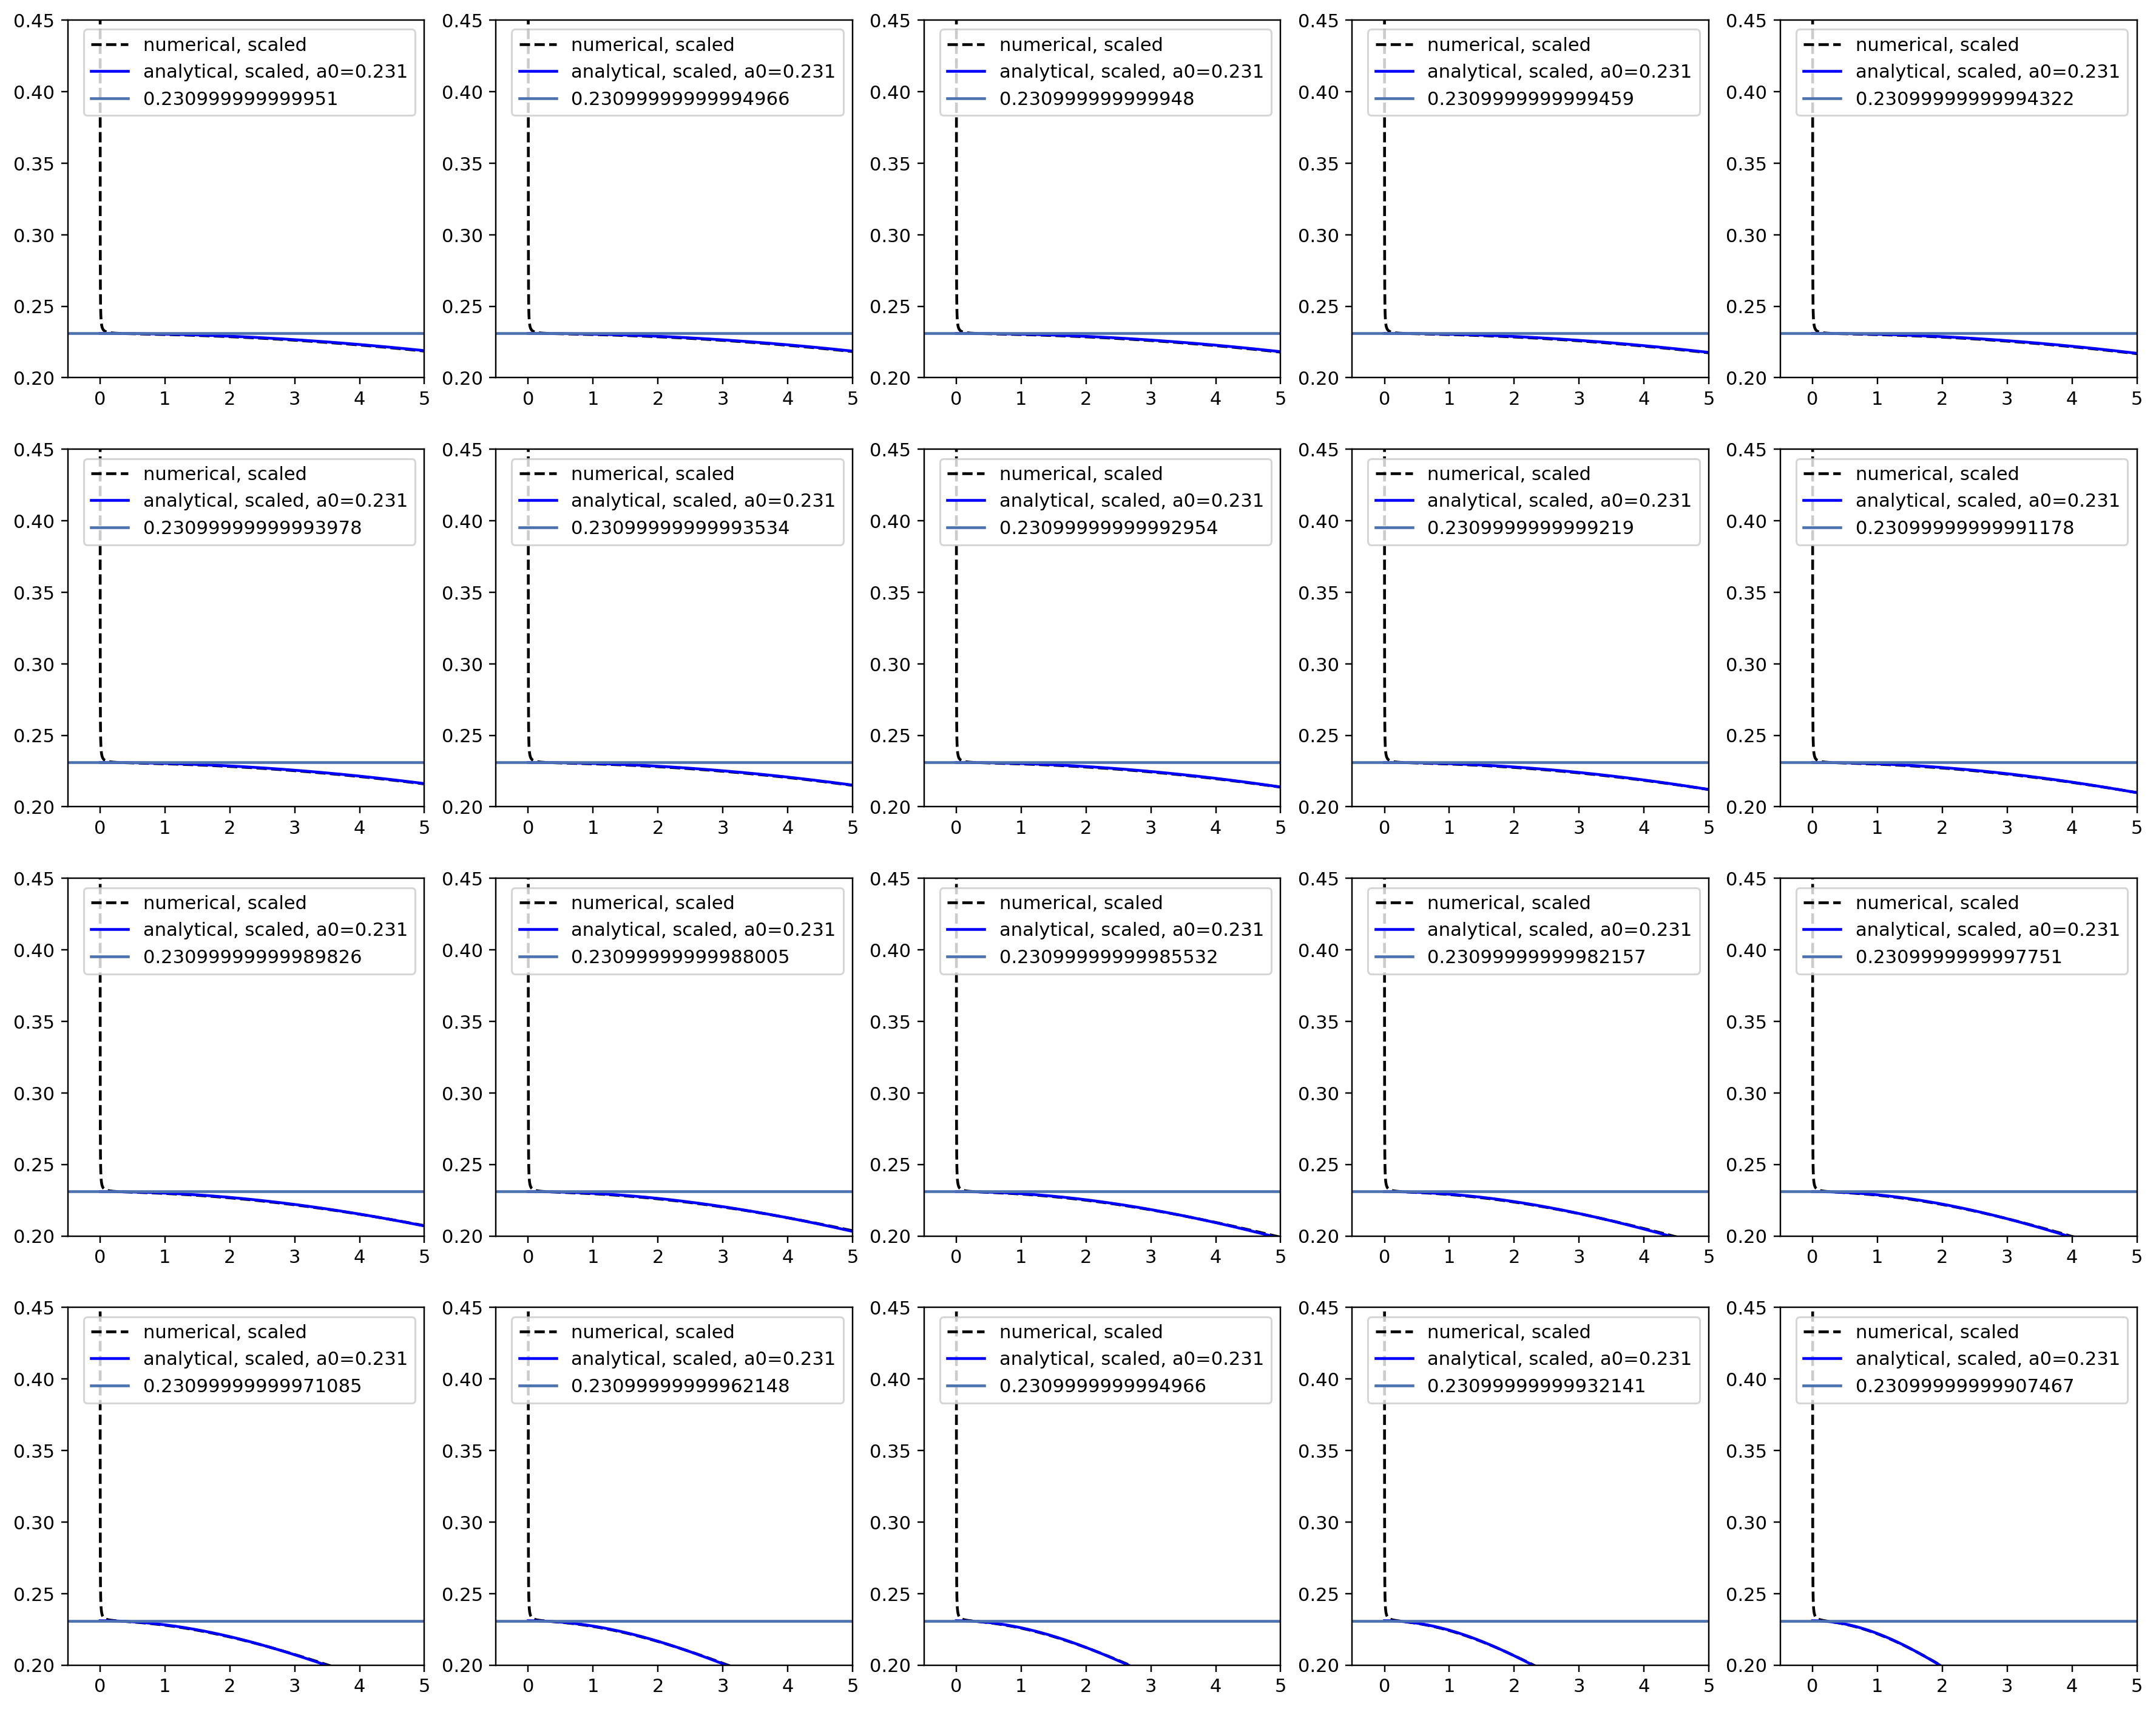

In [ ]:
K_cgs = 1.6e5
PcArr = np.logspace(33.5, 36.5, 20)
K, PcArr = cgs_to_geom(PcArr, 1, K_cgs)[:2]

fig, axs = plt.subplots(4, 5, figsize=(20,16), dpi=220)

for nnn in range(0,20):

    solToUseID = nnn

    RArr = np.array(Rgrid[solToUseID])
    H00r = np.array(H00Grid[solToUseID][:,0])
    DH00r = np.array(H00Grid[solToUseID][:,1])

    # Index at stellar surface
    SurfaceIndex = arrLenAll[solToUseID] - 4
    
    pc = PcArr[solToUseID]

    # Using scaled numerical h00 to determine the scaling factor a0 to use
    scaledH00Num = H00r[startIndex:SurfaceIndex]/(RArr[startIndex:SurfaceIndex]**2)
    sliceWidth = int(SurfaceIndex*0.005)
    for i in range(startIndex, SurfaceIndex-sliceWidth):
        # Compute the variance of scaled h00 within the slice
        varNumH00 = np.var(scaledH00Num[i:i + sliceWidth])
        if varNumH00 < 10**(-8): break

    # Computing the analytical expression
    h00Analytical = h00_series_from_mathematica(RArr, K, pc, a0=int(scaledH00Num[i]*10**3)/(10**3), a8=0)


    startIndex = 0   #int(SurfaceIndex/230)
    
    # Plotting numerical h00


    # Scaled Plot
    axs[nnn//5, nnn%5].plot(RArr[startIndex:SurfaceIndex], scaledH00Num, label="numerical, scaled", color="black", ls="--")
    axs[nnn//5, nnn%5].plot(RArr[startIndex:SurfaceIndex], h00Analytical[startIndex:SurfaceIndex], label=f"analytical, scaled, a0={int(scaledH00Num[i]*10**3)/(10**3)}", color="blue")
    # axs[nnn//5, nnn%5].set_yscale("log")
    axs[nnn//5, nnn%5].set_ylim(0.20,0.45)
    axs[nnn//5, nnn%5].set_xlim(-0.5, 5)
    axs[nnn//5, nnn%5].axhline(h00Analytical[startIndex:SurfaceIndex][0], label=f"{h00Analytical[startIndex:SurfaceIndex][0]}")

    # print(i, i/SurfaceIndex, scaledH00Num[i])
    # axs[nnn//5, nnn%5].axhline(scaledH00Num[i], label="%4f" % scaledH00Num[i])

    

    # print(scaledH00Num[startIndex:SurfaceIndex][2], RArr[startIndex:SurfaceIndex][2]**2)
    # break

    # Unsclaed Plot (Uncomment the block below)
    # axs[nnn//5, nnn%5].plot(RArr[startIndex:SurfaceIndex], H00r[startIndex:SurfaceIndex], label="numerical, not scaled", color="black", ls="--")
    # axs[nnn//5, nnn%5].scatter(RArr[startIndex:SurfaceIndex], H00r[startIndex:SurfaceIndex], label="numerical, not scaled", color="black")
    # Plotting analytical, up to r^6
    # axs[nnn//5, nnn%5].plot(RArr[startIndex:SurfaceIndex], h00Analytical[startIndex:SurfaceIndex], label=r"analytical, not scaled, a0=0.23", color="blue")
    # axs[nnn//5, nnn%5].plot(RArr[startIndex:SurfaceIndex], 0.23*(RArr[startIndex:SurfaceIndex]**2), label=r"analytical, not scaled, a0=0.23", color="blue")



    # axs[nnn//5, nnn%5].set_xlim(-0.01, 0.01)
    # axs[nnn//5, nnn%5].set_ylim(-10**(-7), 10**(-5))
    

    
    axs[nnn//5, nnn%5].legend()


    

$h_{00}/r^2$

## Without expanding $h_{00}$

2.0000000000000005e-09 0.0004 -0.00521103533529359 342.0563908781904
1.1395123160246665e-06 0.0010260618979324146 0.4596533936738738 4.271497575702369


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_13296/1964660890.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


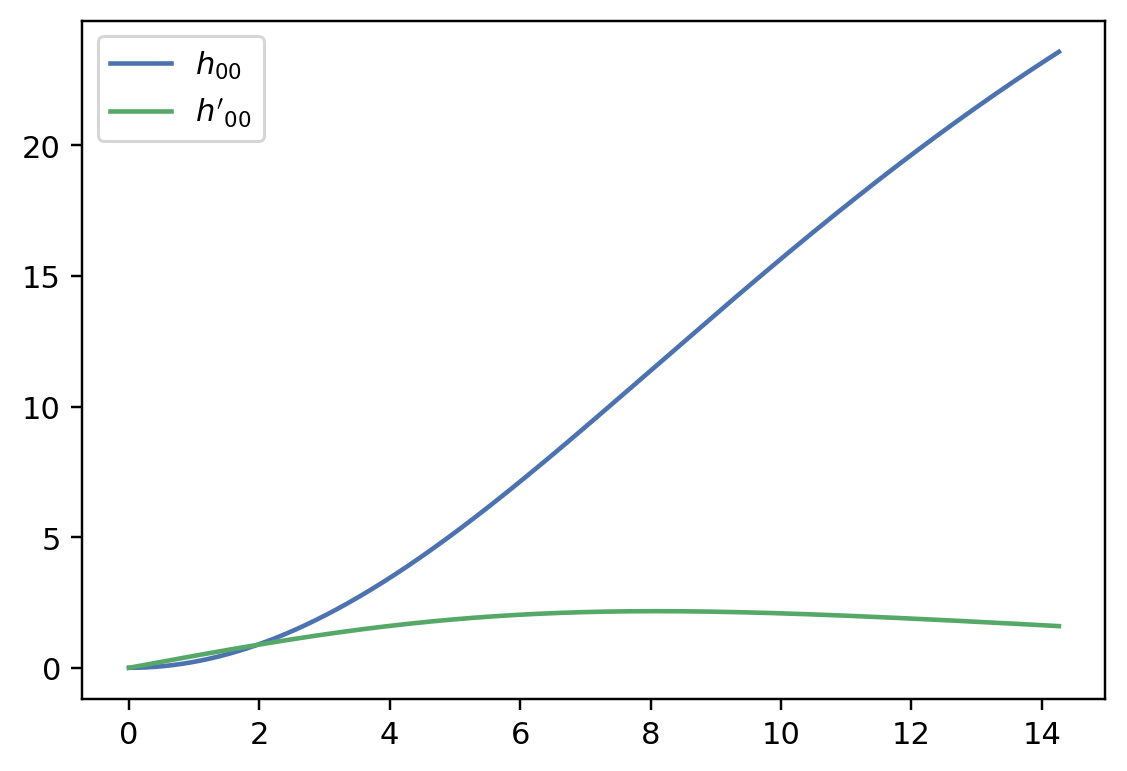

In [ ]:
# Checking behavior of orders of derivatives of h00 

plt.figure(figsize = (6,4), dpi = 220)
for nnn in range(0,20):

    if nnn == 10:

        solToUseID = nnn

        RArr = np.array(Rgrid[solToUseID])
        H00r = np.array(H00Grid[solToUseID][:,0])
        DH00r = np.array(H00Grid[solToUseID][:,1])
        D2H00r = np.gradient(DH00r, RArr[:len(DH00r)])
        D3H00r = np.gradient(D2H00r, RArr[:len(D2H00r)])

        minLen = min(len(H00r), len(DH00r), len(D2H00r), len(D3H00r))

        print(H00r[0], DH00r[0], D2H00r[0], D3H00r[0])
        print(H00r[6], DH00r[6], D2H00r[6], D3H00r[6])

        indexToStart = 0


        plt.plot(RArr[10:minLen-5], H00r[10:minLen-5], label=r"$h_{00}$")
        plt.plot(RArr[indexToStart:minLen-5], DH00r[indexToStart:minLen-5], label=r"$h'_{00}$")
        # plt.plot(RArr[indexToStart:minLen-5], D2H00r[indexToStart:minLen-5], label=r"$h''_{00}$")
        # plt.plot(RArr[indexToStart:minLen-5], D3H00r[indexToStart:minLen-5], label=r"$h^{(3)}_{00}$")

    plt.legend()


In [ ]:
anal_source_o3_original_h00 = []
anal_source_o5_original_h00 = []
anal_source_o7_original_h00 = []
# Constants Needed (r, K, pc, nuc, h00, h00p, T)

K_cgs = 1.6e5
PcArr = np.logspace(33.5, 36.5, 20)
K, PcArr = cgs_to_geom(PcArr, 1, K_cgs)[:2]

for nnn in tqdm(range(0,20)):
    solToUseID = nnn
    
    RArr = np.array(Rgrid[solToUseID])
    H00r = np.array(H00Grid[solToUseID][:,0])
    DH00r = np.array(H00Grid[solToUseID][:,1])
    
    # Index at stellar surface
    SurfaceIndex = arrLenAll[solToUseID] - 4
    
    pc = PcArr[solToUseID]
    # T = 6*10**(-6) 
    NuArr = NuGrid[solToUseID]
    nuc = NuArr[0]

    anal_source_o3_original_h00.append(source_analytical_o3_noh00(RArr[:SurfaceIndex], K, pc, nuc, H00r[:SurfaceIndex], DH00r[:SurfaceIndex], T))
    anal_source_o5_original_h00.append(source_analytical_o5_noh00(RArr[:SurfaceIndex], K, pc, nuc, H00r[:SurfaceIndex], DH00r[:SurfaceIndex], T))
    anal_source_o7_original_h00.append(source_analytical_o7_noh00(RArr[:SurfaceIndex], K, pc, nuc, H00r[:SurfaceIndex], DH00r[:SurfaceIndex], T))
    # anal_source_o7_original_h00.append(source_analytical_o7(RArr, K, pc, nuc, h2, T))

100%|██████████| 20/20 [00:00<00:00, 45.80it/s]


100%|██████████| 20/20 [00:00<00:00, 137.43it/s]


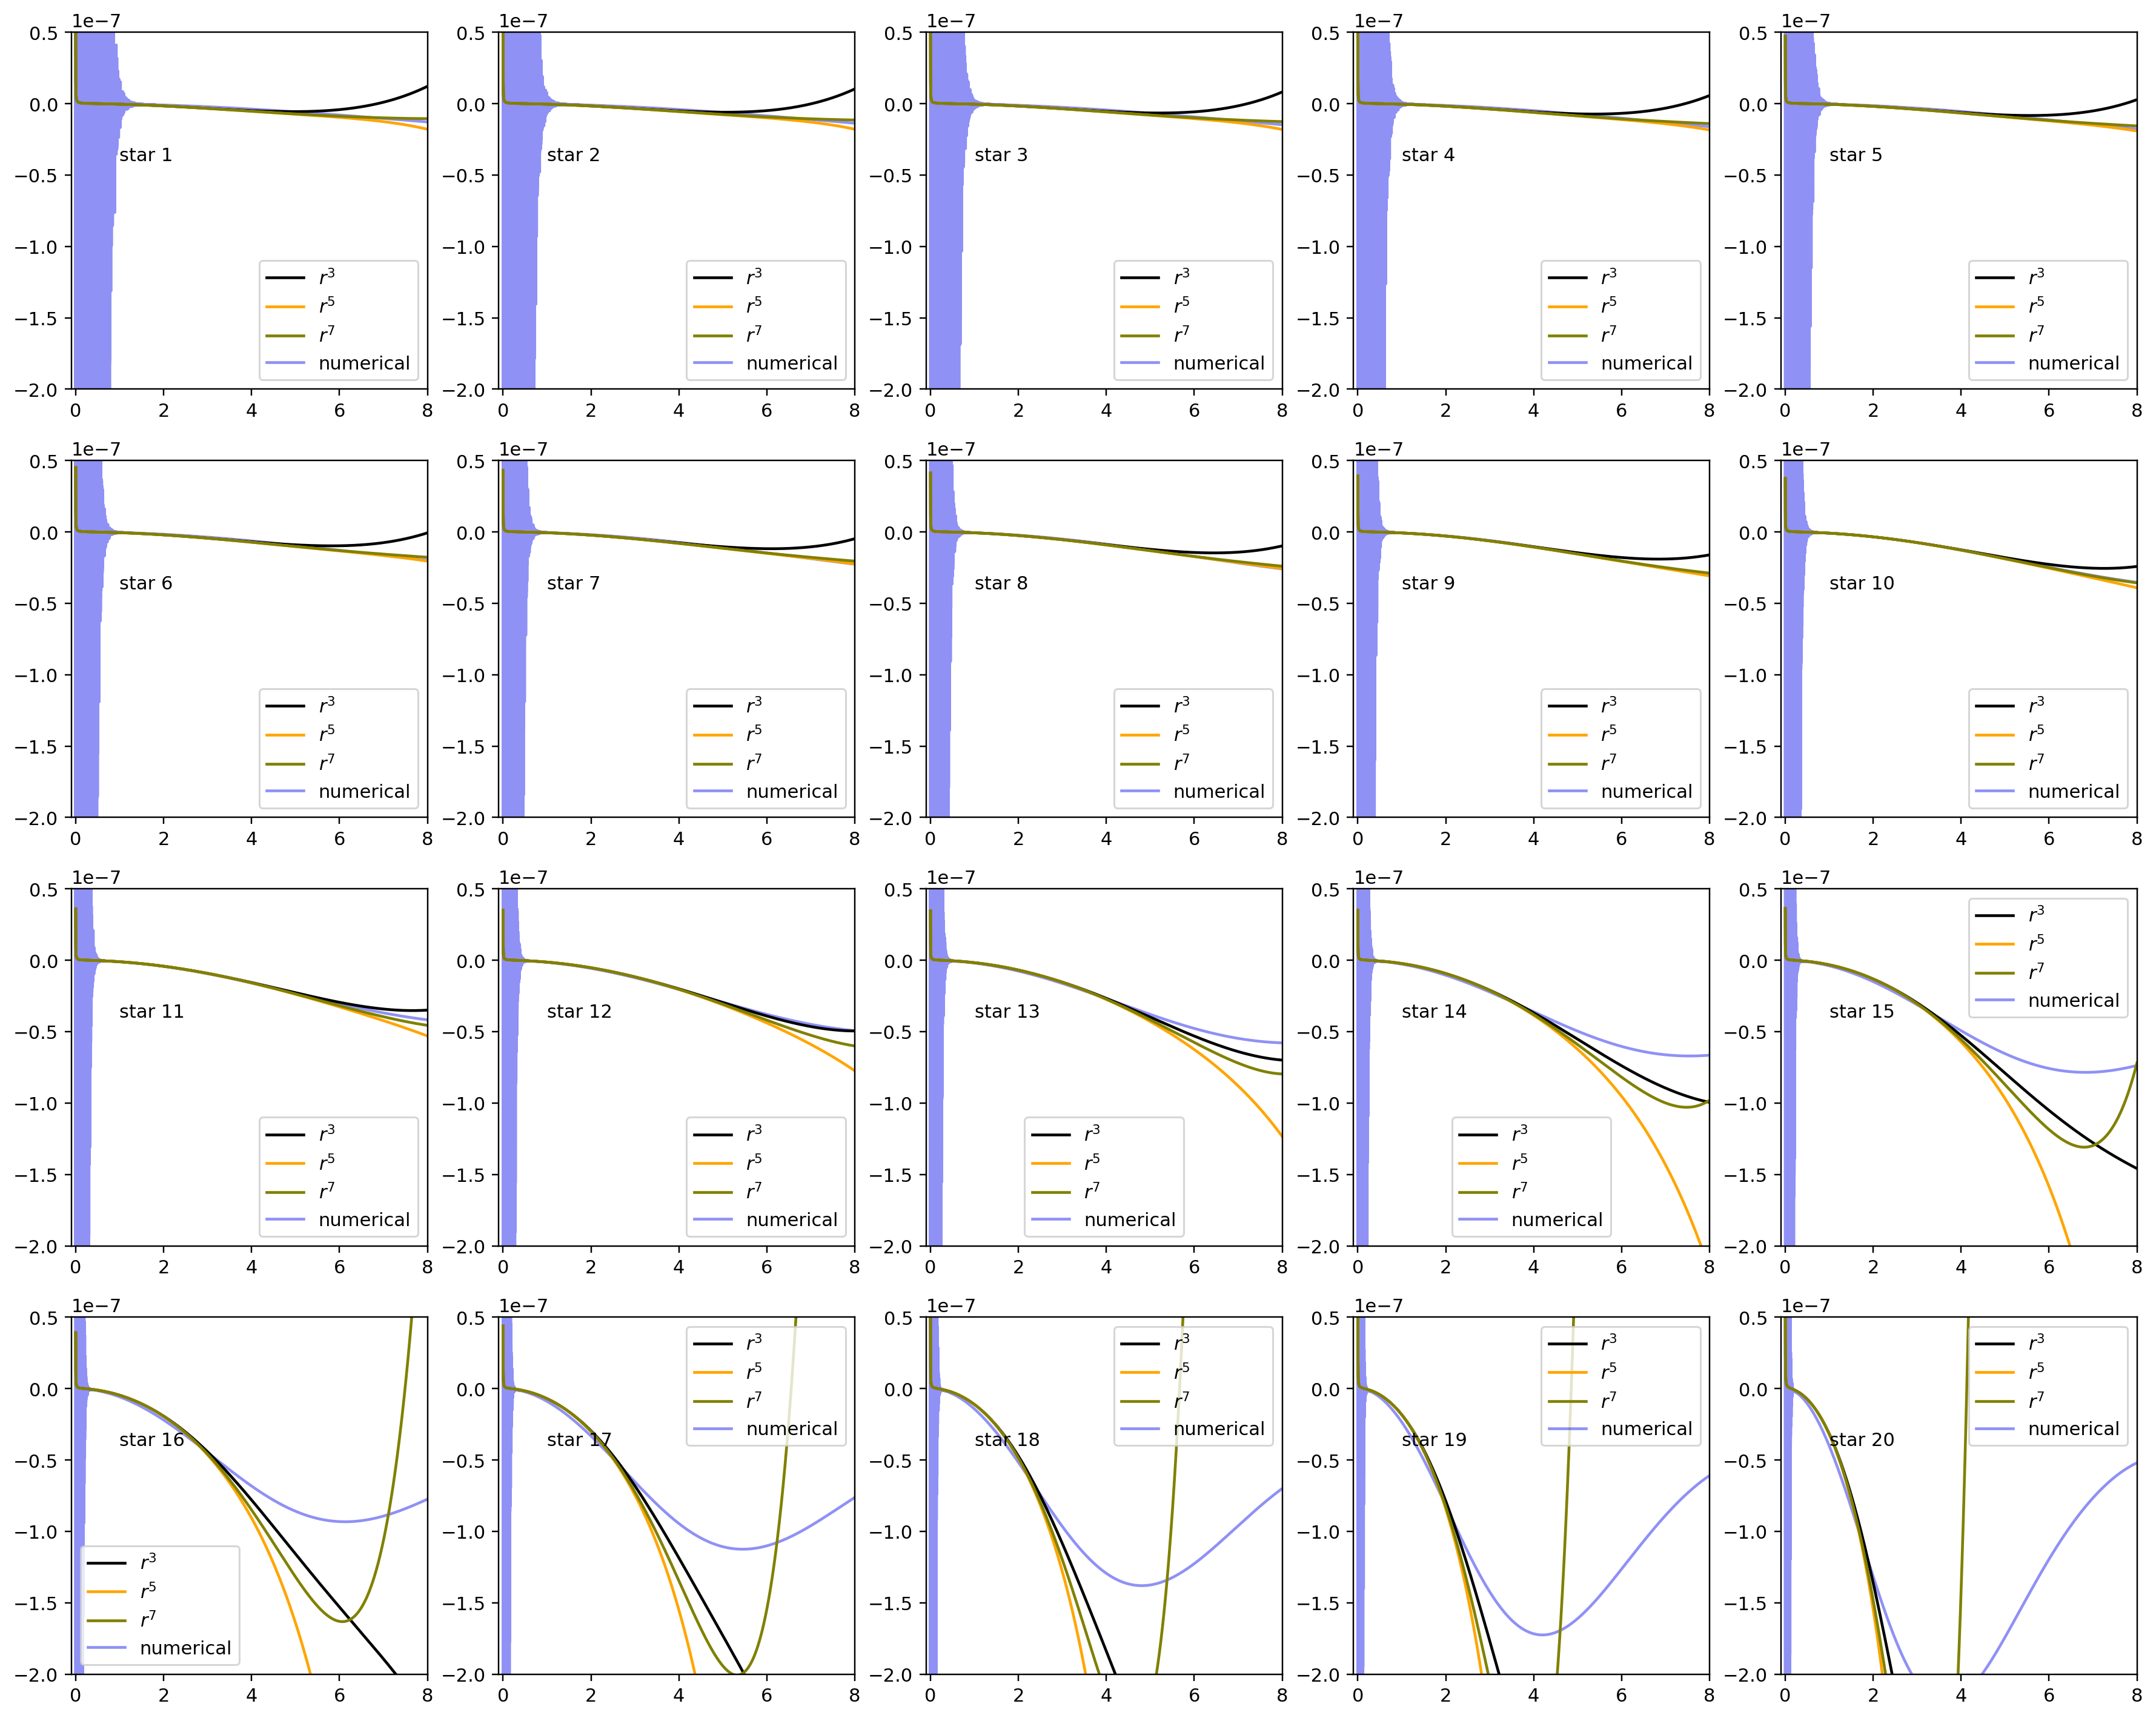

In [ ]:
fig, axs = plt.subplots(4, 5, figsize=(20,16), dpi=220)

for nnn in tqdm(range(0,20)):

    solToUseID = int(nnn)
    
    RArr = np.array(Rgrid[solToUseID])
    SurfaceIndex = arrLenAll[solToUseID] - 4

    # Index at stellar surface
    SurfaceIndex = arrLenAll[solToUseID] - 4

    startIndex = 4   #int(SurfaceIndex/230)
    
    axs[nnn//5, nnn%5].plot(RArr[startIndex:SurfaceIndex], anal_source_o3_original_h00[solToUseID][startIndex:SurfaceIndex], label=r"$r^3$", color="black")
    axs[nnn//5, nnn%5].plot(RArr[startIndex:SurfaceIndex], anal_source_o5_original_h00[solToUseID]
    [startIndex:SurfaceIndex], label=r"$r^5$",color="orange")
    axs[nnn//5, nnn%5].plot(RArr[startIndex:SurfaceIndex], anal_source_o7_original_h00[solToUseID]
    [startIndex:SurfaceIndex], label=r"$r^7$",color="olive")
    # axs[nnn//5, nnn%5].plot(RArr, anal_source_o7_original_h00[solToUseID], label=r"$r^7$")

    
    axs[nnn//5, nnn%5].plot(RArr[startIndex:SurfaceIndex], SourceGrid[solToUseID][startIndex:SurfaceIndex].imag, zorder=-100, label="numerical", color="#2025ed", alpha=0.5)

    axs[nnn//5, nnn%5].set_ylim(-2e-7,5e-8)
    axs[nnn//5, nnn%5].set_xlim(-0.1,8)
    axs[nnn//5, nnn%5].text(1, -4e-8, f"star {nnn+1}")
    axs[nnn//5, nnn%5].legend()


100%|██████████| 20/20 [00:00<00:00, 73.26it/s]


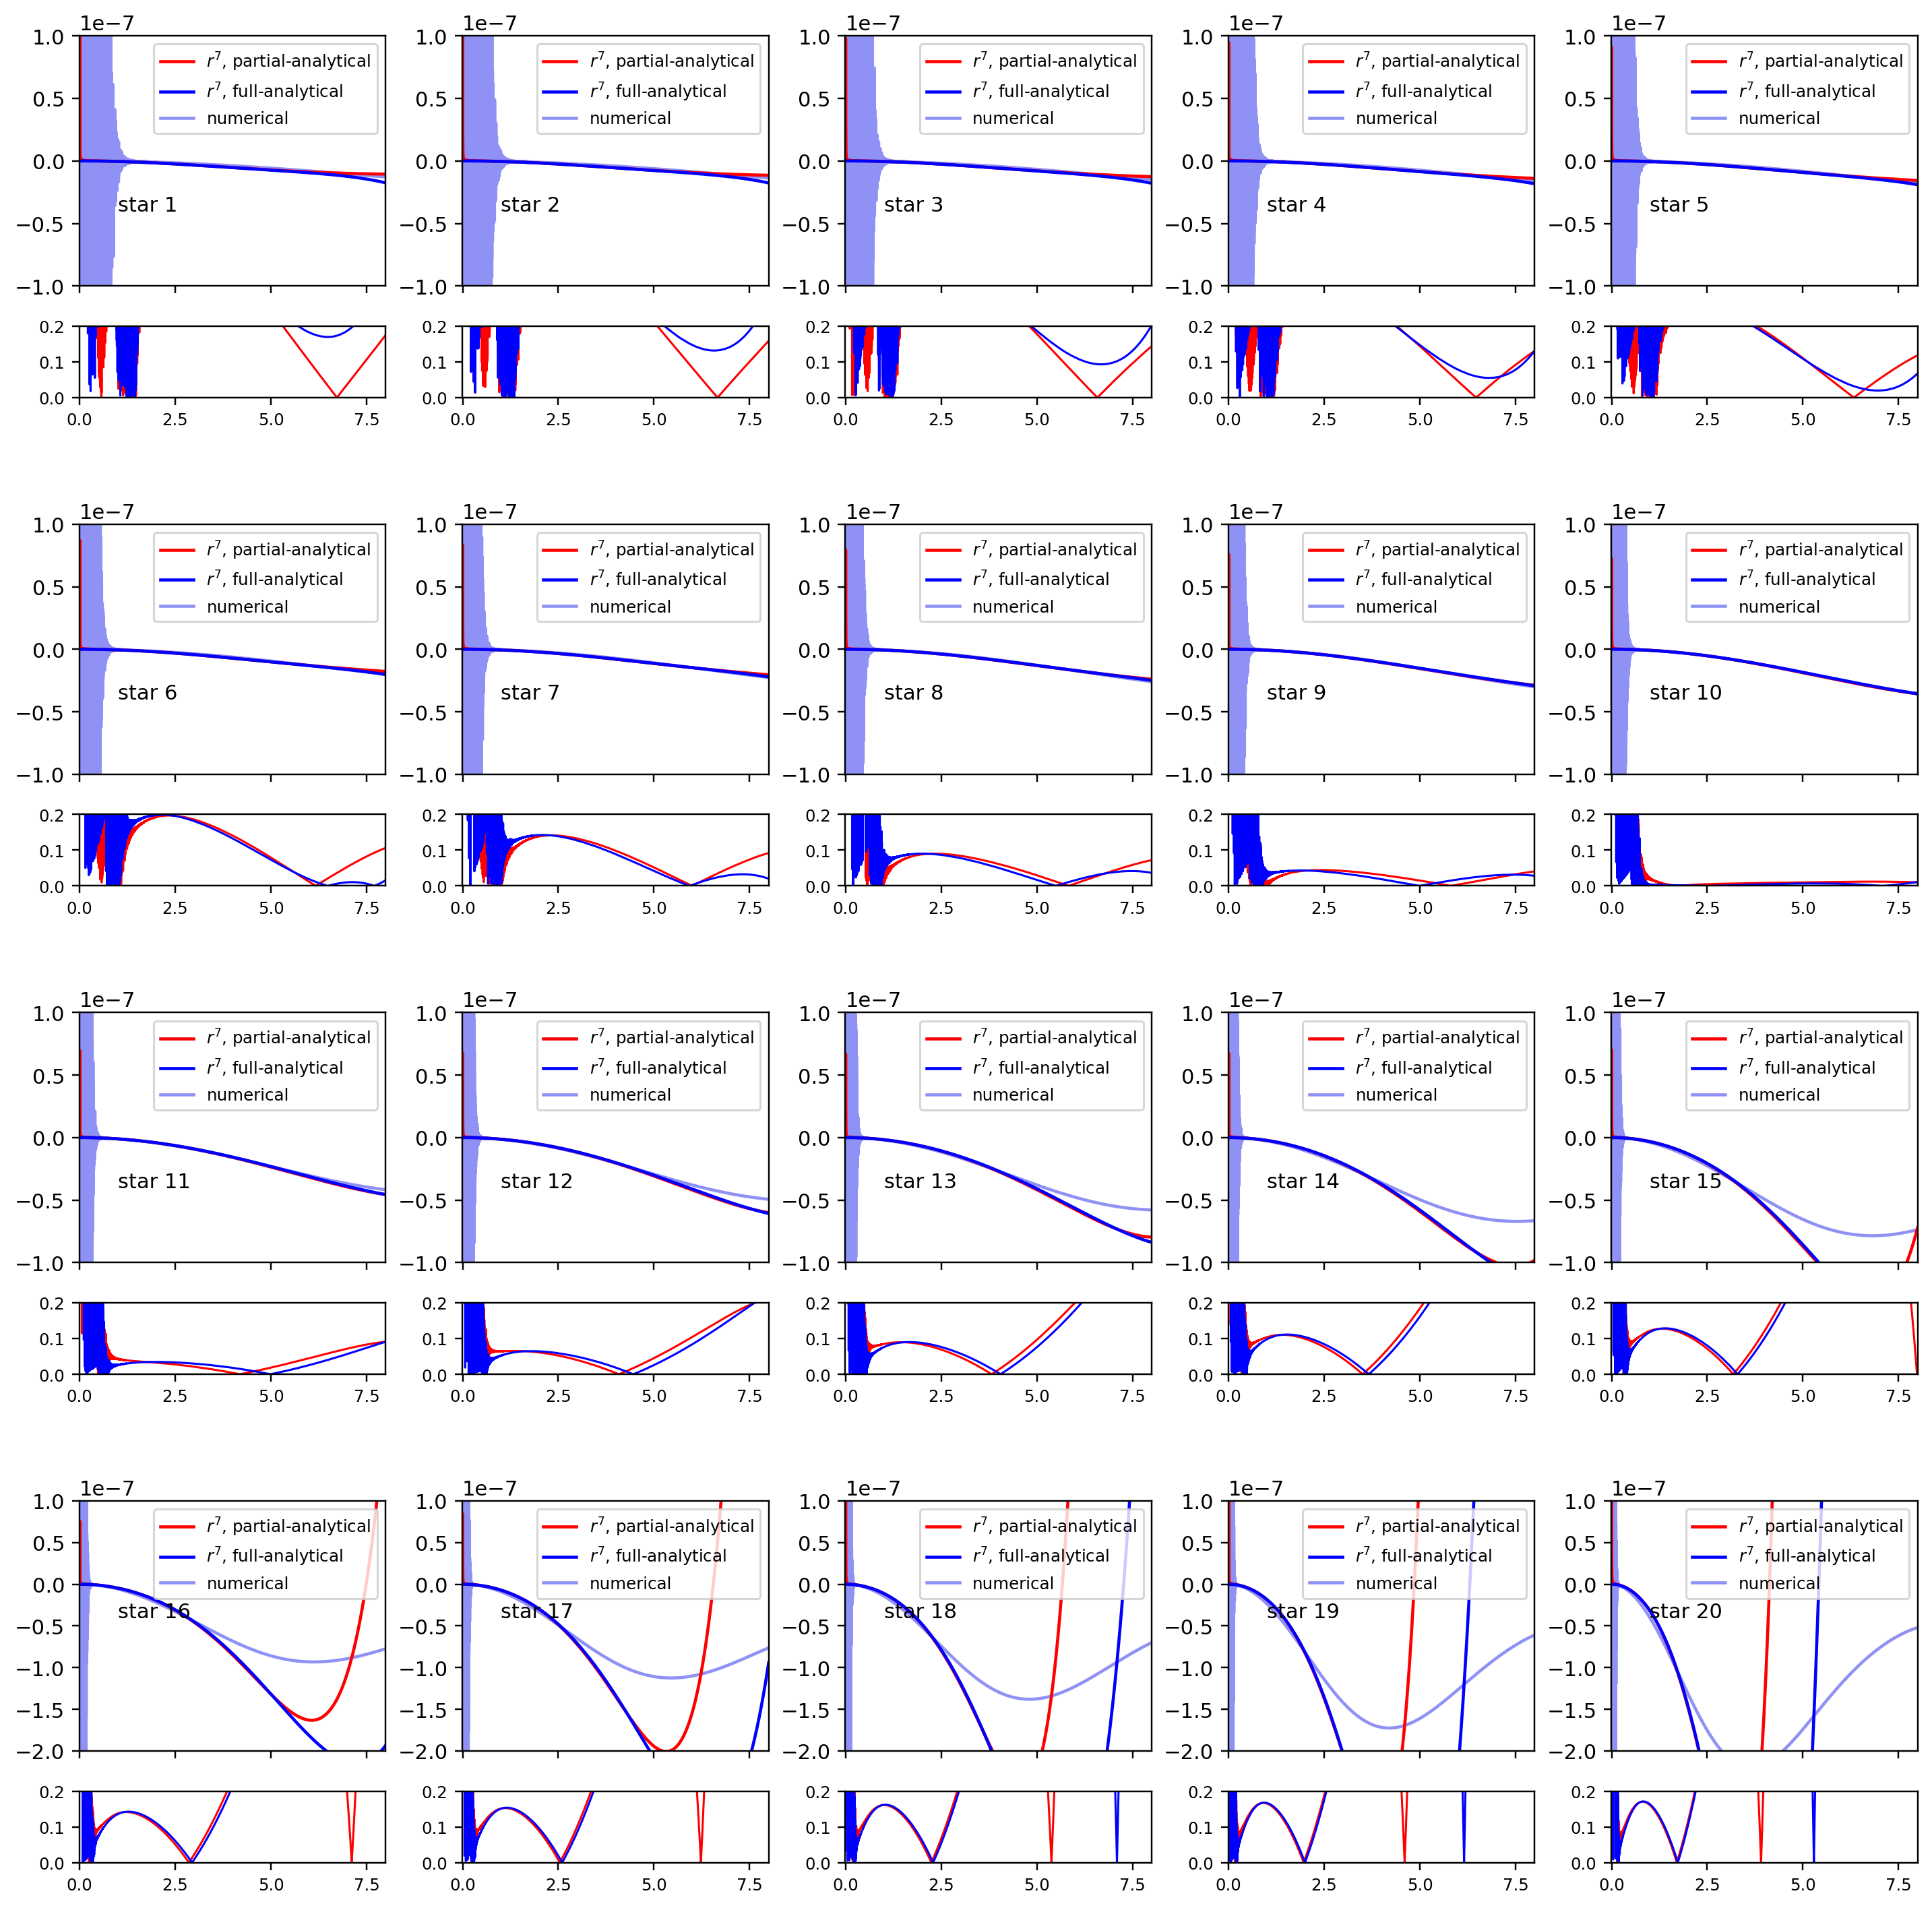

In [ ]:
fig = plt.figure(figsize=(16, 16), dpi=220)
outer = fig.add_gridspec(4, 5, wspace=0.25, hspace=0.35)

for nnn in tqdm(range(0, 20)):
    solToUseID = int(nnn)

    RArr = np.array(Rgrid[solToUseID])
    SurfaceIndex = arrLenAll[solToUseID] - 4

    startIndex = 0 # int(SurfaceIndex / 230)

    # --- dividing in subplots ---
    inner = outer[nnn // 5, nnn % 5].subgridspec(
        2, 1, height_ratios=[3.5, 1], hspace=0.25
    )
    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    # =========================
    # Top panel: comparison of analytical and numerical
    # =========================
    # ax_top.plot(
    #     RArr[:SurfaceIndex],
    #     anal_source_o3_original_h00[solToUseID][:SurfaceIndex],
    #     label=r"$r^3$",
    #     color="black",
    # )
    # ax_top.plot(
    #     RArr[:SurfaceIndex],
    #     anal_source_o5_original_h00[solToUseID][:SurfaceIndex],
    #     label=r"$r^5$",
    #     color="orange",
    # )
    ax_top.plot(
        RArr[:SurfaceIndex],
        anal_source_o7_original_h00[solToUseID][:SurfaceIndex],
        label=r"$r^7$, partial-analytical",
        color="red",
    )
    ax_top.plot(
        RArr[:SurfaceIndex],
        anal_source_o7_v2[solToUseID][:SurfaceIndex],
        label=r"$r^7$, full-analytical",
        color="blue",
    )
    

    src_imag = np.array(SourceGrid[solToUseID]).imag
    ax_top.plot(
        RArr[startIndex:SurfaceIndex],
        src_imag[startIndex:SurfaceIndex],
        zorder=-100,
        label="numerical",
        color="#2025ed",
        alpha=0.5,
    )

    ax_top.set_ylim(-1e-7, 1e-7)
    if nnn >= 15:
        ax_top.set_ylim(-2e-7, 1e-7)
    ax_top.set_xlim(-0.01, 8)
    ax_top.text(1, -4e-8, f"star {nnn+1}")
    ax_top.legend(fontsize=8)

    # No tick text on x-axis
    ax_top.tick_params(labelbottom=False)

    # =========================
    # Bottom Plots (numerical - analytic)
    # =========================


    softening = np.max(np.abs(src_imag[int(SurfaceIndex*0.1): int(SurfaceIndex*0.2)]))*0.1

    # print(softening)
    
    diff_o3 = np.abs(src_imag - np.array(anal_source_o3_original_h00[solToUseID]))/(np.abs(src_imag) + softening)
    diff_o5 = np.abs(src_imag - np.array(anal_source_o5_original_h00[solToUseID]))/(np.abs(src_imag) + softening)
    diff_o7 = np.abs(src_imag - np.array(anal_source_o7_original_h00[solToUseID]))/(np.abs(src_imag) + softening)
    diff_o7_v2 = np.abs(src_imag - np.array(anal_source_o7_v2[solToUseID][:SurfaceIndex]))/(np.abs(src_imag) + softening)

    ax_bot.axhline(0.0, lw=0.8, alpha=0.6)
    # ax_bot.plot(
    #     RArr[startIndex:SurfaceIndex],
    #     diff_o3[startIndex:SurfaceIndex],
    #     color="black",
    #     label=r"num - $r^3$",
    #     lw=1.0,
    # )
    # ax_bot.plot(
    #     RArr[startIndex:SurfaceIndex],
    #     diff_o5[startIndex:SurfaceIndex],
    #     color="orange",
    #     label=r"num - $r^5$",
    #     lw=1.0,
    # )
    ax_bot.plot(
        RArr[startIndex:SurfaceIndex],
        diff_o7[startIndex:SurfaceIndex],
        color="red",
        label=r"error, partial-analytical$\mathcal{O}(r^7)$",
        lw=1.0,
    )

    ax_bot.plot(
        RArr[startIndex:SurfaceIndex],
        diff_o7_v2[startIndex:SurfaceIndex],
        color="blue",
        label=r"error, full-analytical$\mathcal{O}(r^7)$",
        lw=1.0,
    )

    # ax_bot.legend(fontsize=8)
    ax_bot.set_ylim(0.0, 0.2)
    # ax_bot.set_yscale("log")
    ax_bot.set_xlim(-0.01, 8)
    ax_bot.tick_params(labelsize=8)

plt.show()


## Identifying the transitioning region

We apply a smooth transition from $r_1$ to $r_2$. 
> * $r_1$ is identified using slide filtering method to obtain the area of the numerical solution has variation lowered to a set number;
> *  $r_2$ is chosen to be the radius first time of crossing of analytical and numerical solution after $r_1$.

100%|██████████| 20/20 [00:00<00:00, 28.86it/s]


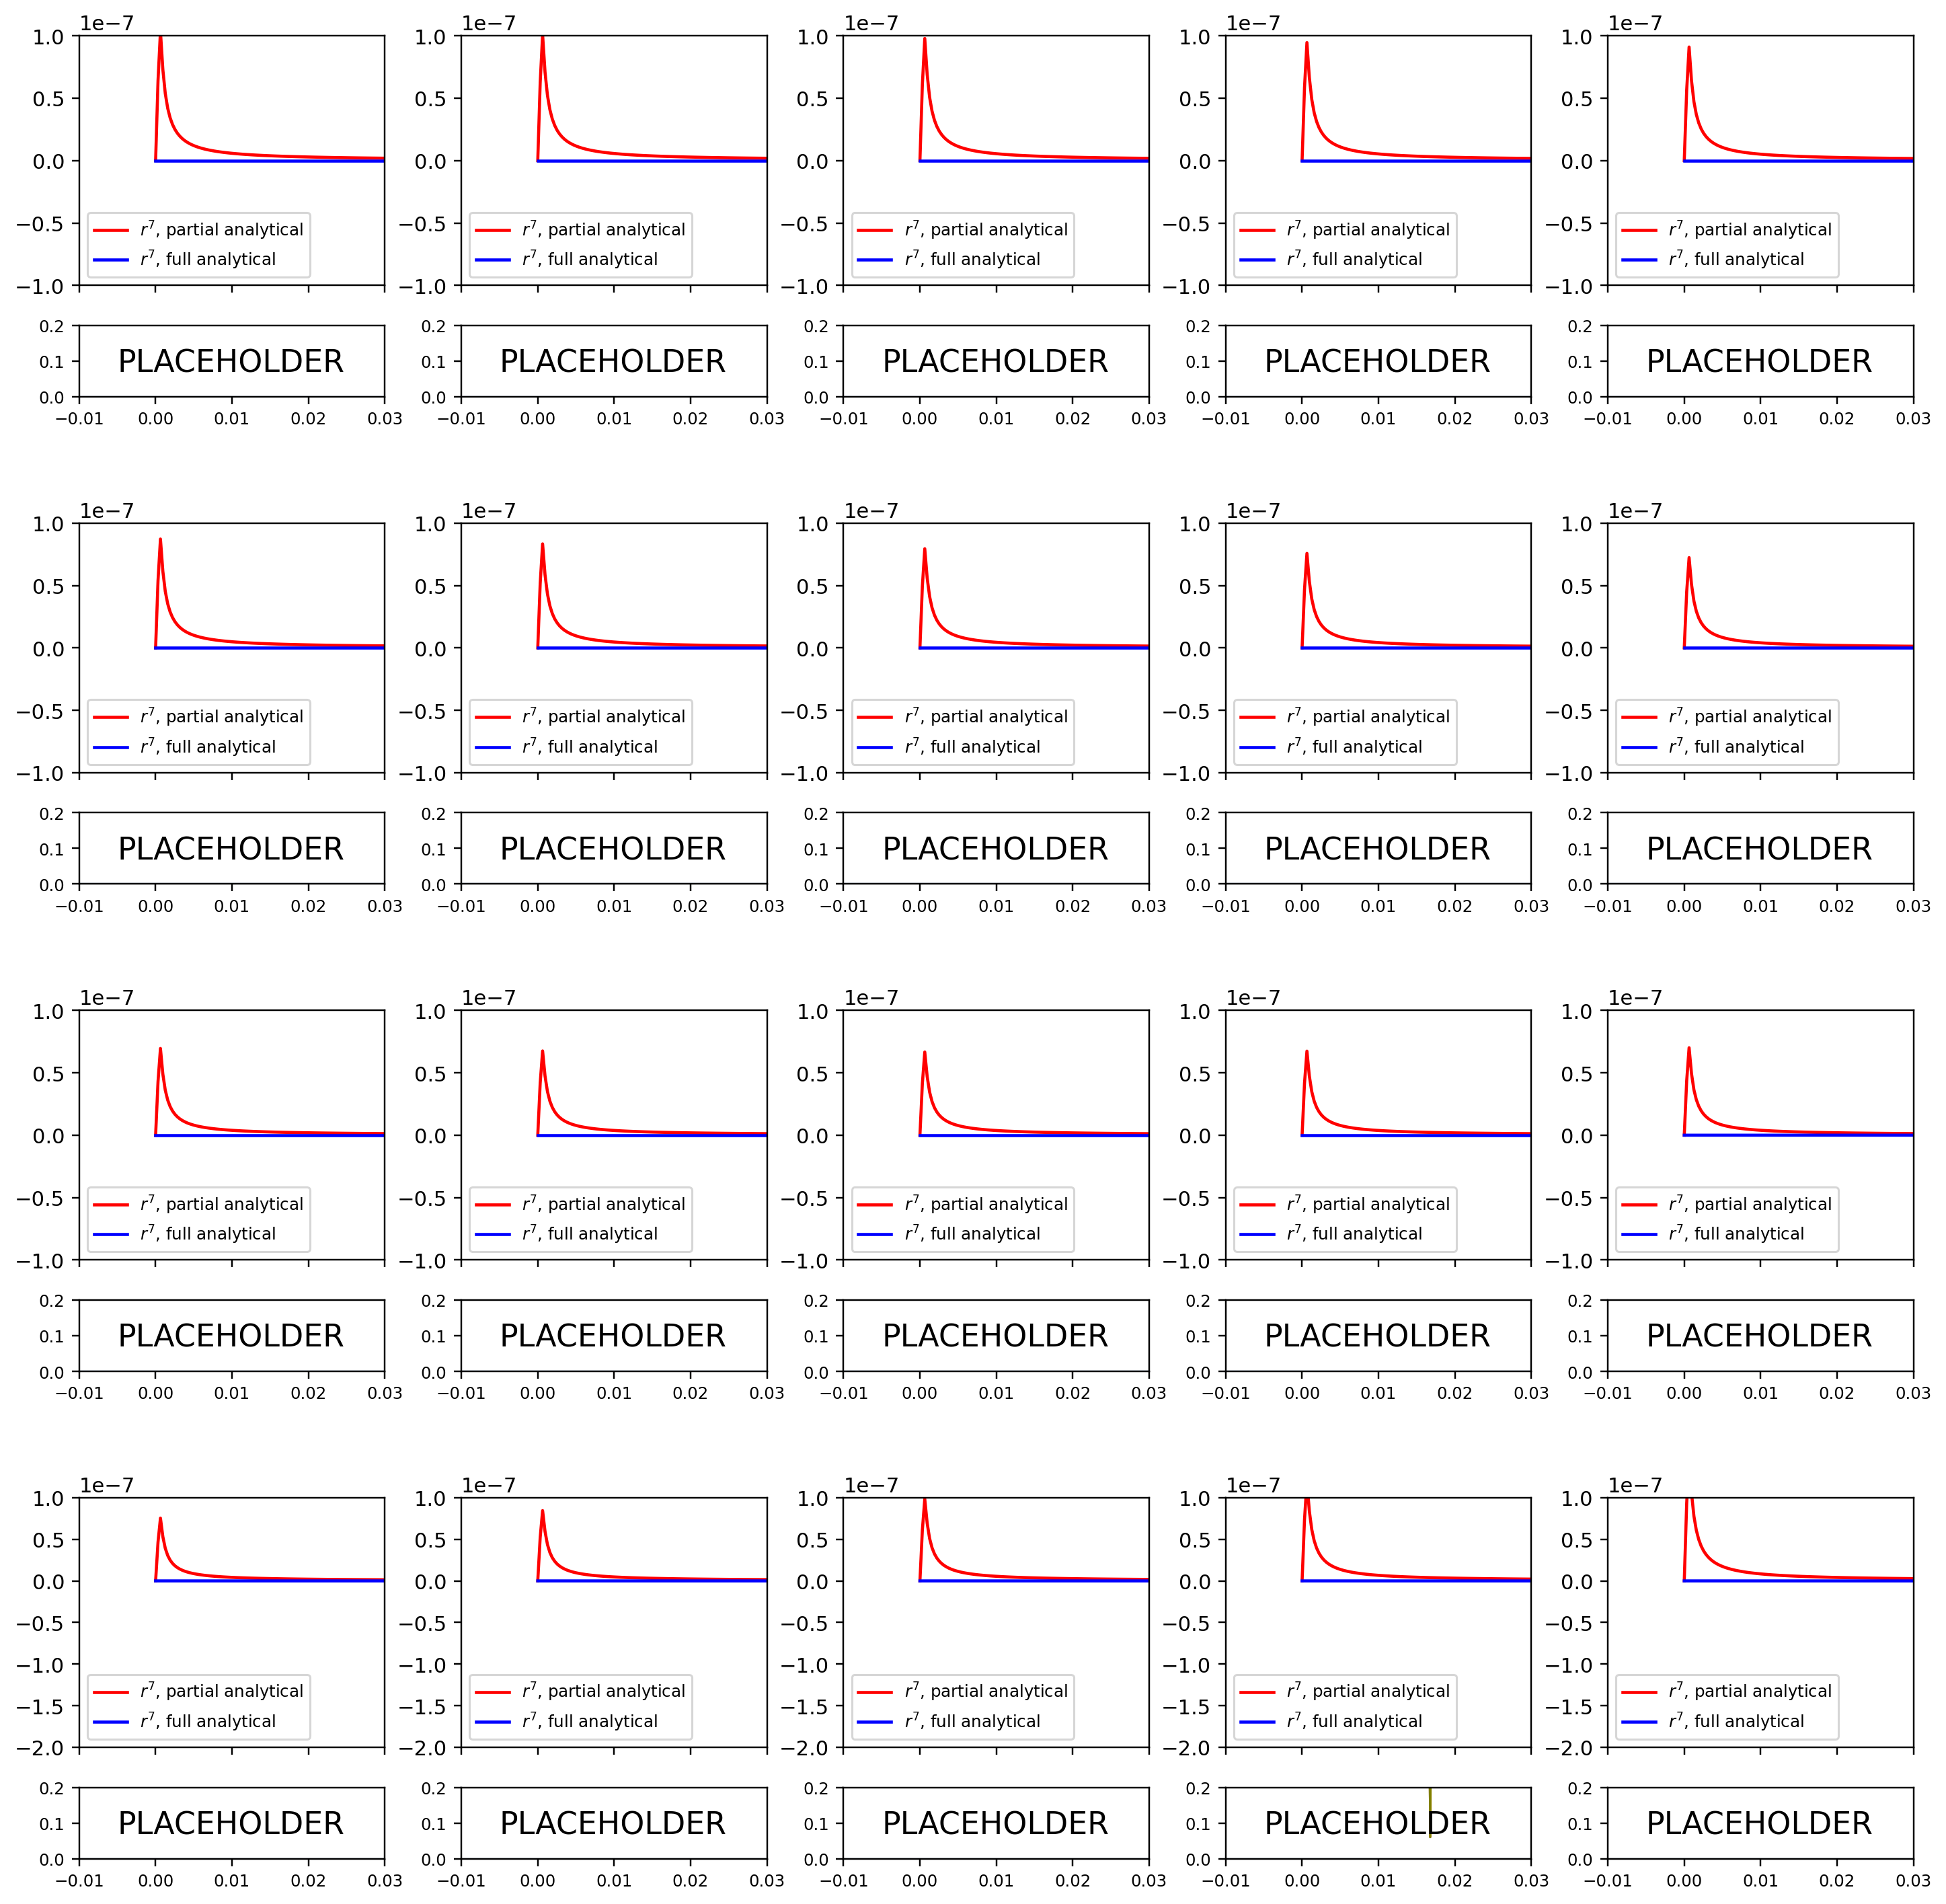

In [ ]:
fig = plt.figure(figsize=(16, 16), dpi=220)
outer = fig.add_gridspec(4, 5, wspace=0.25, hspace=0.35)

r1Index_ARR = []
r2Index_ARR = []

for nnn in tqdm(range(0, 20)):
    solToUseID = int(nnn)

    RArr = np.array(Rgrid[solToUseID])
    SurfaceIndex = arrLenAll[solToUseID] - 4

    startIndex = 0 # int(SurfaceIndex / 230)

    # --- dividing in subplots ---
    inner = outer[nnn // 5, nnn % 5].subgridspec(
        2, 1, height_ratios=[3.5, 1], hspace=0.25
    )
    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    # =========================
    # Top panel: comparison of analytical and numerical
    # =========================
    # ax_top.plot(
    #     RArr[:SurfaceIndex],
    #     anal_source_o3_original_h00[solToUseID][:SurfaceIndex],
    #     label=r"$r^3$",
    #     color="black",
    # )
    # ax_top.plot(
    #     RArr[:SurfaceIndex],
    #     anal_source_o5_original_h00[solToUseID][:SurfaceIndex],
    #     label=r"$r^5$",
    #     color="orange",
    # )
    ax_top.plot(
        RArr[:SurfaceIndex],
        anal_source_o7_original_h00[solToUseID][:SurfaceIndex],
        label=r"$r^7$, partial analytical",
        color="red",
    )
    ax_top.plot(
        RArr[:SurfaceIndex],
        anal_source_o7_v2[solToUseID][:SurfaceIndex],
        label=r"$r^7$, full analytical",
        color="blue",
    )


    src_imag = np.array(SourceGrid[solToUseID]).imag
    # ax_top.plot(
    #     RArr[startIndex:SurfaceIndex],
    #     src_imag[startIndex:SurfaceIndex],
    #     zorder=-100,
    #     label="numerical",
    #     color="#2025ed",
    #     alpha=0.5,
    # )

    ax_top.set_ylim(-1e-7, 1e-7)
    if nnn >= 15:
        ax_top.set_ylim(-2e-7, 1e-7)
    ax_top.set_xlim(-0.01, 8)
    # ax_top.text(1, -4e-8, f"star {nnn+1}")
    ax_top.legend(fontsize=8)

    # No tick text on x-axis
    ax_top.tick_params(labelbottom=False)

    # =========================
    # Bottom Plots (numerical - analytic)
    # =========================


    softening = np.max(np.abs(src_imag[int(SurfaceIndex*0.1): int(SurfaceIndex*0.2)]))*0.1

    # print(softening)
    
    diff_o3 = np.abs(src_imag - np.array(anal_source_o3_original_h00[solToUseID]))/(np.abs(src_imag) + softening)
    diff_o5 = np.abs(src_imag - np.array(anal_source_o5_original_h00[solToUseID]))/(np.abs(src_imag) + softening)
    diff_o7 = np.abs(src_imag - np.array(anal_source_o7_original_h00[solToUseID]))/(np.abs(src_imag) + softening)

    ax_bot.axhline(0.0, lw=0.8, alpha=0.6)
    ax_bot.plot(
        RArr[startIndex:SurfaceIndex],
        diff_o3[startIndex:SurfaceIndex],
        color="black",
        label=r"num - $r^3$",
        lw=1.0,
    )
    ax_bot.plot(
        RArr[startIndex:SurfaceIndex],
        diff_o5[startIndex:SurfaceIndex],
        color="orange",
        label=r"num - $r^5$",
        lw=1.0,
    )
    ax_bot.plot(
        RArr[startIndex:SurfaceIndex],
        diff_o7[startIndex:SurfaceIndex],
        color="olive",
        label=r"num - $r^7$",
        lw=1.0,
    )


    ax_bot.set_ylim(0.0, 0.2)
    # ax_bot.set_yscale("log")
    ax_bot.set_xlim(-0.01, 0.03)
    ax_bot.tick_params(labelsize=8)



    # Identifying inner radius r1
    filterwidth = int(0.005 * SurfaceIndex )
    for r1 in range(0, SurfaceIndex - filterwidth):
        num_std = np.std(src_imag[r1: r1 + filterwidth])
        if num_std < 10**(-9.5):
            break

    # Plotting r1 indicator
    ax_top.axvline(x=RArr[r1], ls = "--", color="black", lw = 0.5)
    ax_bot.axvline(x=RArr[r1], ls = "--", color="black", lw = 0.5)
    

    # Identifying inner radius r2

    # ind_check = np.array([int(a) for a in [0.01* r1, 0.02* r1, 0.03* r1]])
    ind_check = np.array([1,2,3])
    # print(ind_check)
    
    for r2 in range(r1*5, SurfaceIndex):
        
        if (diff_o7[r2 - ind_check[2]] < diff_o7[r2 - ind_check[1]]) and (diff_o7[r2 - ind_check[1]] < diff_o7[r2 - ind_check[0]]) and (diff_o7[r2 - ind_check[0]] < diff_o7[r2]):
            if (diff_o7[r2 + ind_check[2]] > diff_o7[r2 + ind_check[1]]) and (diff_o7[r2 + ind_check[1]] > diff_o7[r2 + ind_check[0]]) and (diff_o7[r2 + ind_check[0]] > diff_o7[r2]):
                break
        
        continue

    # Plotting r1 indicator
    ax_top.axvline(x=RArr[r2], ls = "--", color="black", lw = 0.5)
    ax_bot.axvline(x=RArr[r2], ls = "--", color="black", lw = 0.5)
    ax_bot.text(x=-0.005, y=0.07, s="PLACEHOLDER", fontsize=15)

    ax_top.axvspan(xmin=RArr[r1], xmax=RArr[r2], color="gray", alpha = 0.2)
    ax_bot.axvspan(xmin=RArr[r1], xmax=RArr[r2], color="gray", alpha = 0.2)

    r1Index_ARR.append(r1)
    r2Index_ARR.append(r2)
            
plt.show()

r1Index_ARR = np.array(r1Index_ARR)
r2Index_ARR = np.array(r2Index_ARR)


## Concatenating the two solutions within the identified transitioning region

We use a quintic smoothstep function on the numerical solution
$$
S = \left\{
    \begin{array}{cl}
    0,& r<r_1\\[4pt]
    6t^5  - 15t^4 + 10t^3 & r\in(r_1, r_2),\\[4pt]
    1,& r<r_2
    \end{array}
\right.
$$
with $t = (r-r_1)/(r_2-r_1)$. With this we have zero first and second derivatives at the endpoints.

In [ ]:
Source_concatGrid = []

def quintic_smooth_step(t):
    return (6*t**5) - (15*t**4) + (10*t**3)

for nnn in tqdm(range(0, 20)):
    solToUseID = int(nnn)

    RArr = np.array(Rgrid[solToUseID])
    r1 = r1Index_ARR[solToUseID]
    r2 = r2Index_ARR[solToUseID]
    SurfaceIndex = arrLenAll[solToUseID] - 4

    tArr = (RArr - RArr[r1])/(RArr[r2] - RArr[r1])
    tArr[tArr <= 0] = 0
    tArr[tArr >= 1] = 1

    tSmooth = quintic_smooth_step(tArr)[:SurfaceIndex]

    o7_analytical = anal_source_o7_v2[solToUseID][:SurfaceIndex]
    src_imag = np.array(SourceGrid[solToUseID]).imag
    

    # print(len(o7_analytical), len(src_imag), len(tSmooth))

    Source_concat = o7_analytical*(1-tSmooth) + src_imag*tSmooth
    Source_concatGrid.append(Source_concat)


100%|██████████| 20/20 [00:00<00:00, 373.65it/s]


100%|██████████| 20/20 [00:00<00:00, 135.15it/s]


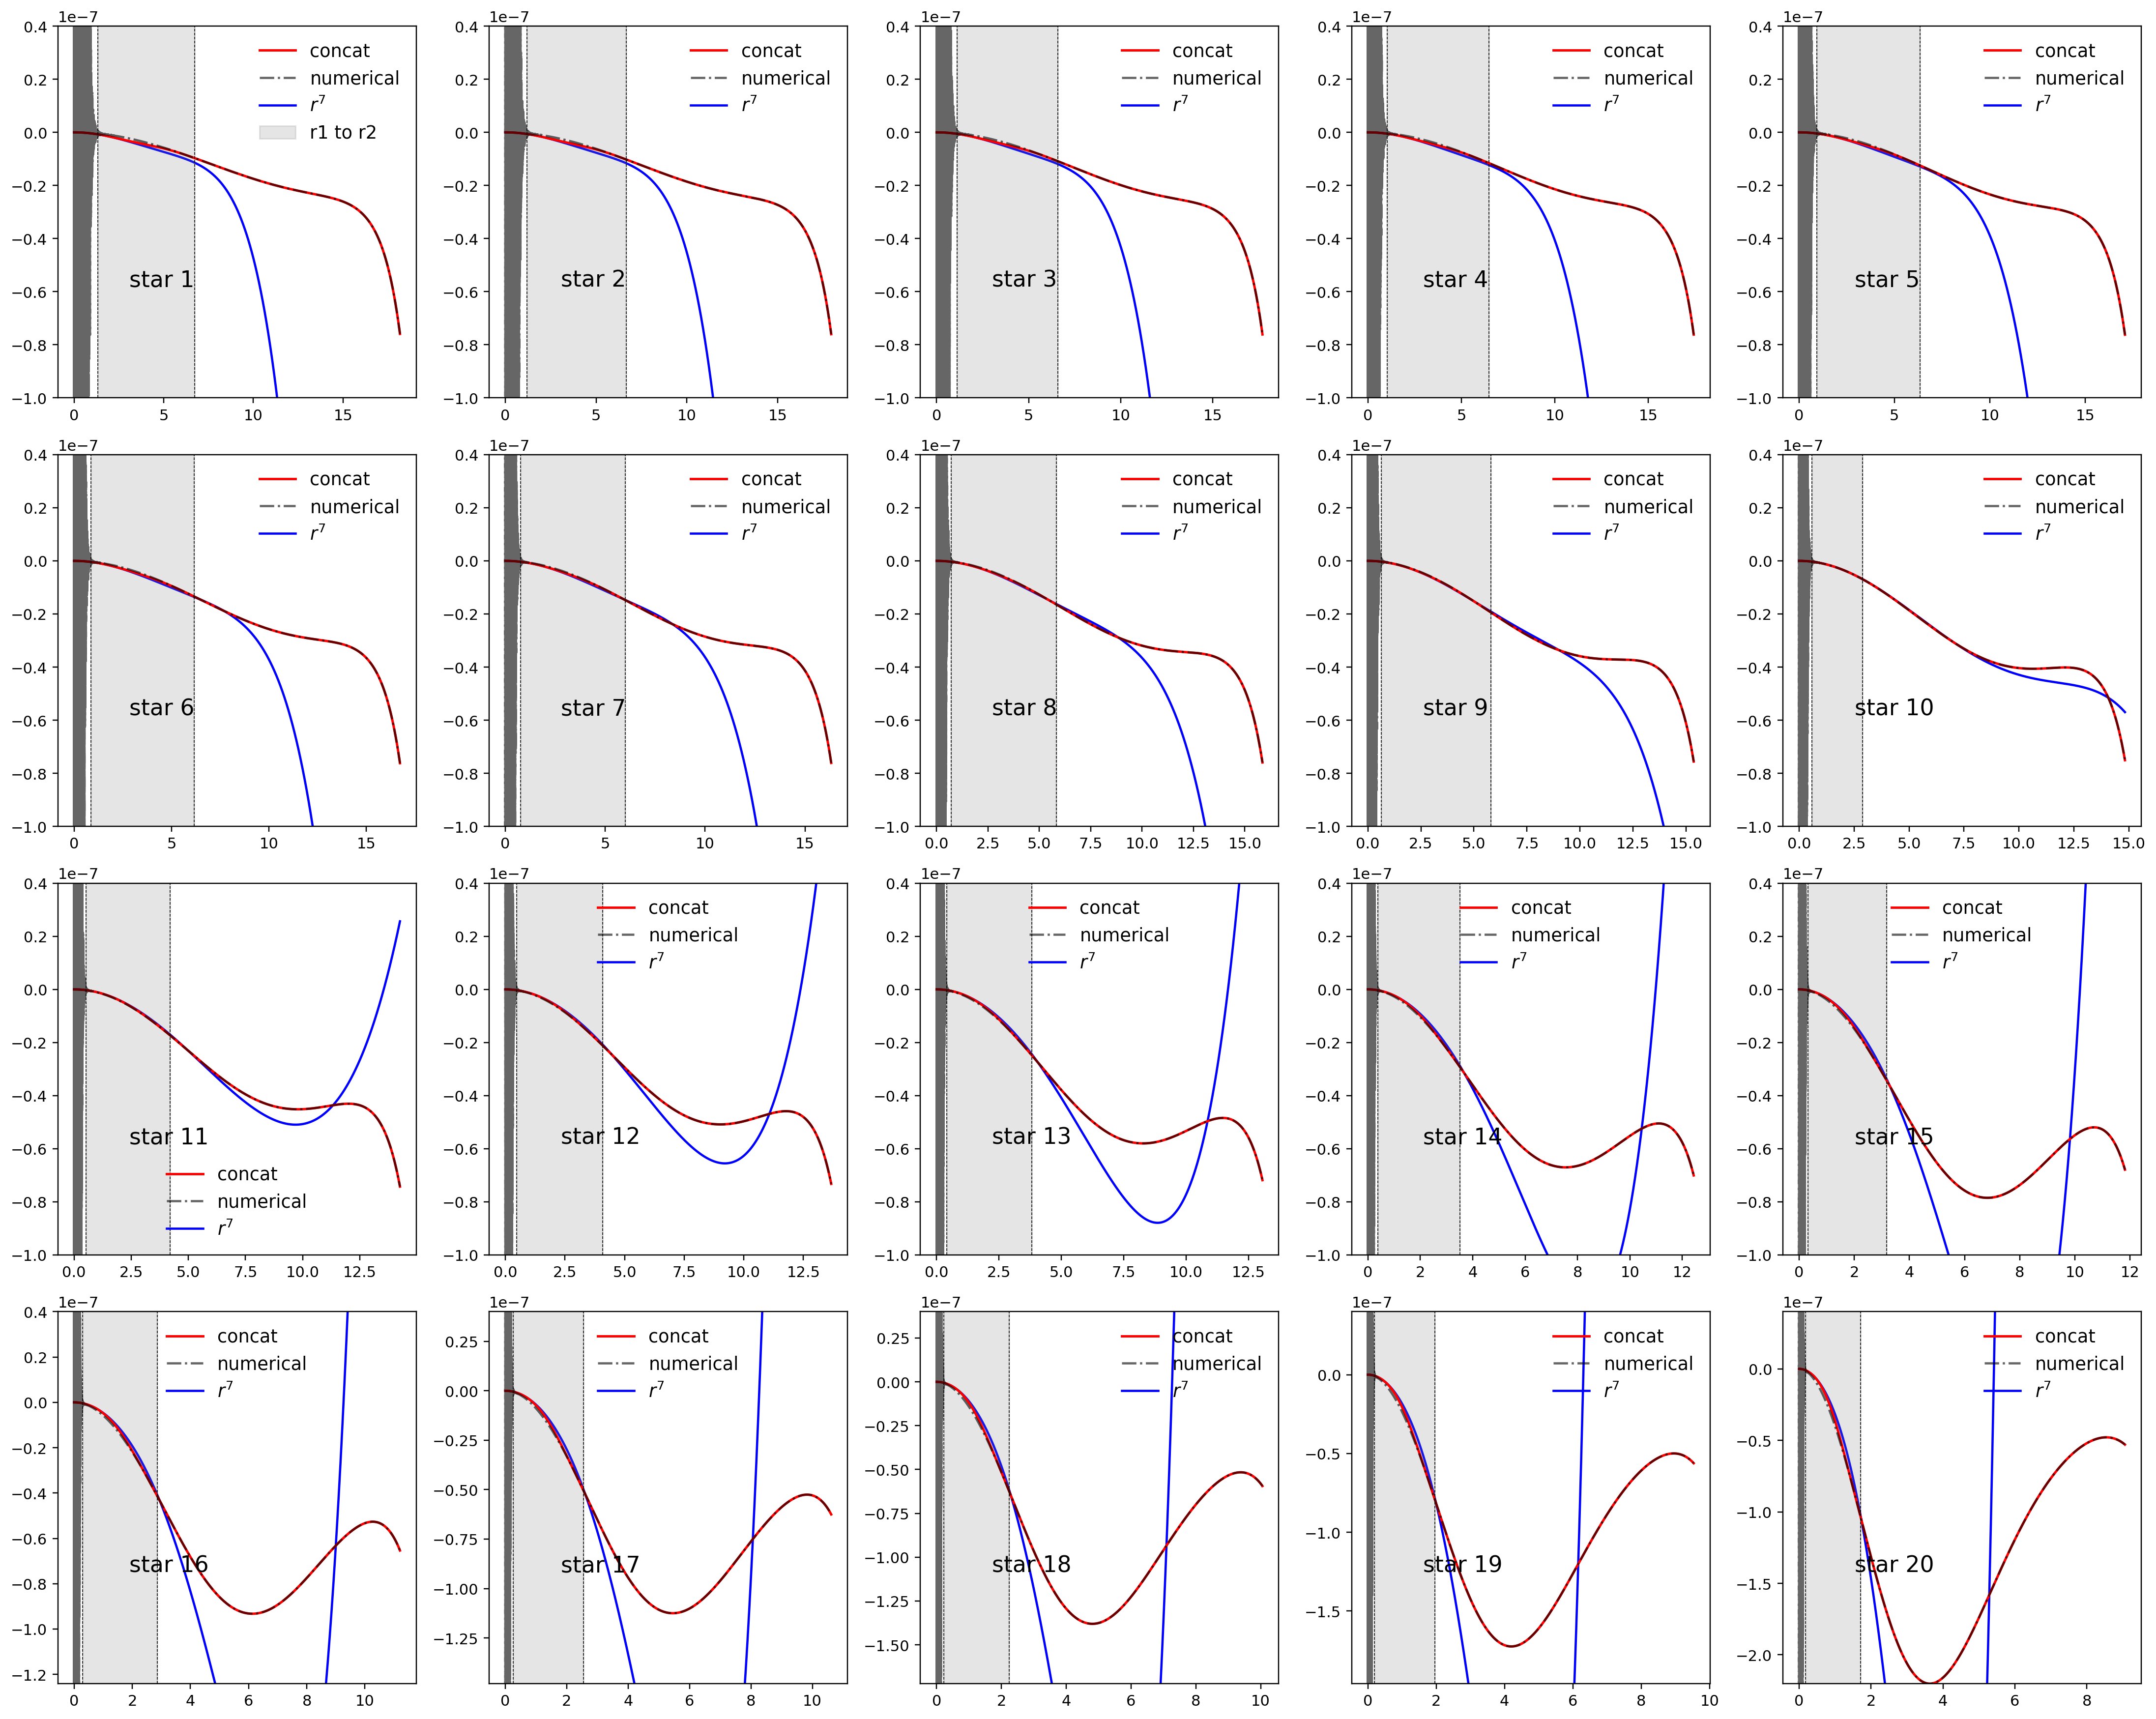

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

fig, axs = plt.subplots(4, 5, figsize=(20, 16), dpi=220)

for nnn in tqdm(range(0, 20)):
    solToUseID = int(nnn)
    ax = axs[nnn // 5, nnn % 5]

    RArr = np.array(Rgrid[solToUseID])
    SurfaceIndex = arrLenAll[solToUseID] - 4
    r1 = r1Index_ARR[solToUseID]
    r2 = r2Index_ARR[solToUseID]

    src_imag = np.array(SourceGrid[solToUseID]).imag
    concat = np.array(Source_concatGrid[solToUseID])
    r7 = np.array(anal_source_o7_v2[solToUseID][:SurfaceIndex])

    ax.plot(
        RArr[:SurfaceIndex],
        concat[:SurfaceIndex],
        label="concat",
        color="red",
        lw=1.6,
    )
    ax.plot(
        RArr[:SurfaceIndex],
        src_imag[:SurfaceIndex],
        label="numerical",
        color="black",
        alpha=0.6,
        ls = "-."
    )
    ax.plot(
        RArr[:SurfaceIndex],
        r7[:SurfaceIndex],
        label=r"$r^7$",
        color="blue",
        zorder=-100
    )

    span_label = "r1 to r2" if nnn == 0 else "_nolegend_"
    ax.axvspan(xmin=RArr[r1], xmax=RArr[r2], color="gray", alpha=0.2, label=span_label)
    ax.axvline(x=RArr[r1], ls="--", color="black", lw=0.5)
    ax.axvline(x=RArr[r2], ls="--", color="black", lw=0.5)

    # ax.set_xlim(-0.01, 8)
    ax.set_ylim(-1e-7, 0.4e-7)
    if nnn > 14: ax.set_ylim(-(1 + 1.2*(nnn-14)/5)*10**(-7), 0.4e-7)
    ax.text(x=0.2, y=0.3, s=f"star {nnn + 1}", transform=ax.transAxes, fontsize=15)
    ax.legend(fontsize=12, frameon=False)

fig.tight_layout()
plt.show()


## Saving the source grid

In [ ]:
# with open("./numpyArr/Source_concatGrid.pkl", "wb") as f:                        
#     pickle.dump(Source_concatGrid, f, protocol=pickle.HIGHEST_PROTOCOL)